## Environment Definition

## Reward Design

In [1]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces

class TradingGymEnv(gym.Env):
    def __init__(
        self,
        df,
        state_features,
        transaction_cost=0.001,
        lambda_vol=0.01,
        lambda_dd=0.02,
        lambda_turnover=0.0,
        lambda_trend=0.0,
        reward_return_weight=3.0,
        reward_clip=None,
        # Reward mode: "new" or "baseline"
        reward_mode="new",
        # Signal regime thresholds
        low_signal_threshold=0.20,
        high_signal_threshold=0.50,
        # Regime reward controls
        low_signal_flat_bonus=0.05,
        low_signal_exposure_penalty=0.03,
        mid_signal_exposure_penalty=0.01,
        high_signal_alignment_reward=0.08,
        high_signal_wrong_way_penalty=0.10,
        extreme_position_penalty=0.01,
        # Trend persistence bonus (HIGH regime only)
        persistence_lookback=4,
        trend_persistence_bonus=0.02,
        # Regime-based position caps
        low_signal_max_abs_position=0.10,
        mid_signal_max_abs_position=0.65,
        high_signal_max_abs_position=1.00,
        # Optional: discourage long inactivity (mild)
        inactivity_penalty=0.0,
        inactivity_threshold=0.25,
        inactivity_window=20,
        # Optional: risk-normalized exposure
        use_risk_normalized_exposure=False,
        volatility_scale=1.0
    ):
        super().__init__()

        self.df = df.reset_index(drop=True).copy()
        self.state_features = state_features
        self.transaction_cost = transaction_cost
        self.lambda_vol = lambda_vol
        self.lambda_dd = lambda_dd
        self.lambda_turnover = lambda_turnover
        self.lambda_trend = lambda_trend
        self.reward_return_weight = reward_return_weight
        self.reward_clip = reward_clip
        self.reward_mode = reward_mode
        self.low_signal_threshold = low_signal_threshold
        self.high_signal_threshold = high_signal_threshold
        self.low_signal_flat_bonus = low_signal_flat_bonus
        self.low_signal_exposure_penalty = low_signal_exposure_penalty
        self.mid_signal_exposure_penalty = mid_signal_exposure_penalty
        self.high_signal_alignment_reward = high_signal_alignment_reward
        self.high_signal_wrong_way_penalty = high_signal_wrong_way_penalty
        self.extreme_position_penalty = extreme_position_penalty
        self.persistence_lookback = persistence_lookback
        self.trend_persistence_bonus = trend_persistence_bonus
        self.low_signal_max_abs_position = low_signal_max_abs_position
        self.mid_signal_max_abs_position = mid_signal_max_abs_position
        self.high_signal_max_abs_position = high_signal_max_abs_position
        self.inactivity_penalty = inactivity_penalty
        self.inactivity_threshold = inactivity_threshold
        self.inactivity_window = inactivity_window
        self.use_risk_normalized_exposure = use_risk_normalized_exposure
        self.volatility_scale = volatility_scale
        self.n_steps = len(self.df)

        required_cols = [
            "raw_return_1d",
            "regime_volatility_raw",
            "MA_gap_raw",
            "trend_strength_raw"
        ]
        missing_cols = [c for c in required_cols if c not in self.df.columns]
        if missing_cols:
            raise ValueError(f"DataFrame is missing required columns: {missing_cols}")

        # Continuous target position in [-1, 1]
        # (kept compatible with PPO continuous actions)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)

        # Optional discrete mapping (for ablation / comparison)
        self.position_levels = np.array(
            [-1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0],
            dtype=np.float32
        )

        # Observation = state_features + current position
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(self.state_features) + 1,),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_step = 0
        self.position = 0.0
        self.target_position = 0.0
        self.total_reward = 0.0
        self.portfolio_value = 1.0
        self.running_max = 1.0

        # Exposure tracking (diagnostics)
        self.exposure_sum = 0.0
        self.exposure_count = 0
        self.low_exposure_steps = 0

        state = self._get_state()
        info = {
            "portfolio_value": self.portfolio_value,
            "position": self.position,
            "target_position": self.target_position,
            "step": self.current_step,
            "market_id": int(self.df.loc[self.current_step, "market_id"]) if "market_id" in self.df.columns else -1,
            "MA_gap_raw": float(self.df.loc[self.current_step, "MA_gap_raw"]) if "MA_gap_raw" in self.df.columns else 0.0,
            "regime_volatility_raw": float(self.df.loc[self.current_step, "regime_volatility_raw"]) if "regime_volatility_raw" in self.df.columns else 0.0,
            "recent_drawdown": float(self.df.loc[self.current_step, "recent_drawdown"]) if "recent_drawdown" in self.df.columns else 0.0,
            "trend_persistence": float(self.df.loc[self.current_step, "trend_persistence"]) if "trend_persistence" in self.df.columns else 0.0
        }
        return state, info

    def _get_state(self):
        market_state = self.df.loc[self.current_step, self.state_features].values.astype(np.float32)
        full_state = np.append(market_state, np.float32(self.position))
        return full_state.astype(np.float32)

    def step(self, action):
        reward = 0.0

        # Stop before next-day return becomes unavailable
        if self.current_step >= self.n_steps - 2:
            terminated = True
            truncated = False
            next_state = np.zeros(len(self.state_features) + 1, dtype=np.float32)
            info = {
                "portfolio_value": self.portfolio_value,
                "position": self.position,
                "step": self.current_step
            }
            return next_state, reward, terminated, truncated, info

        # Risk penalties (use RAW volatility to avoid scaled leakage)
        current_vol_raw = float(self.df.loc[self.current_step, "regime_volatility_raw"])

        # Raw signal values (unscaled) for reward logic
        ma_gap_raw = float(self.df.loc[self.current_step, "MA_gap_raw"])
        trend_strength_raw = float(self.df.loc[self.current_step, "trend_strength_raw"])
        signal_strength_raw = abs(ma_gap_raw) / (current_vol_raw + 1e-6)
        signal_strength = float(np.clip(signal_strength_raw / 10.0, 0.0, 1.0))

        if signal_strength < self.low_signal_threshold:
            signal_regime = "LOW"
            max_abs_position = self.low_signal_max_abs_position
        elif signal_strength < self.high_signal_threshold:
            signal_regime = "MID"
            max_abs_position = self.mid_signal_max_abs_position
        else:
            signal_regime = "HIGH"
            max_abs_position = self.high_signal_max_abs_position

        # Continuous action -> capped target position by regime
        raw_action = float(np.asarray(action).item())
        raw_action = float(np.clip(raw_action, -1.0, 1.0))
        target_position = float(np.clip(raw_action, -max_abs_position, max_abs_position))

        # Optional risk-normalized exposure (reduce leverage in high vol)
        effective_position = target_position
        if self.use_risk_normalized_exposure:
            effective_position = target_position / (1 + self.volatility_scale * current_vol_raw)
        effective_position = float(np.clip(effective_position, -max_abs_position, max_abs_position))

        # Transaction cost depends on how much position changes
        position_change = abs(effective_position - self.position)
        trade_cost = position_change * self.transaction_cost

        # Apply new position (effective)
        self.target_position = target_position
        self.position = float(effective_position)

        # Next-day raw return drives PnL
        next_return = float(self.df.loc[self.current_step + 1, "raw_return_1d"])
        pnl = self.position * next_return

        # True net trading return (used for portfolio accounting)
        net_return = pnl - trade_cost

        current_vol = current_vol_raw
        current_drawdown = max(
            0.0,
            (self.running_max - self.portfolio_value) / (self.running_max + 1e-8)
        )

        # Use raw trend strength for reward logic
        trend_strength = trend_strength_raw
        weak_signal = signal_regime == "LOW"

        # Selective-participation reward update
        if self.reward_mode == "baseline":
            # Baseline reward (no trend bonus)
            reward_return = net_return
            reward_vol_penalty = -self.lambda_vol * current_vol
            reward_dd_penalty = -self.lambda_dd * current_drawdown
            reward = reward_return + reward_vol_penalty + reward_dd_penalty
            reward_breakdown = {
                "reward_return": reward_return,
                "reward_trend": 0.0,
                "reward_cash_bonus": 0.0,
                "reward_vol_penalty": reward_vol_penalty,
                "reward_dd_penalty": reward_dd_penalty,
                "reward_exposure_penalty": 0.0,
                "reward_turnover_penalty": 0.0,
                "reward_alignment_bonus": 0.0,
                "reward_wrong_way_penalty": 0.0,
                "reward_extreme_position_penalty": 0.0
            }
        else:
            # New reward: selective participation by signal regime
            reward_return = self.reward_return_weight * net_return
            reward_trend = 0.0
            reward_cash_bonus = 0.0
            reward_exposure_penalty = 0.0
            reward_alignment_bonus = 0.0
            reward_wrong_way_penalty = 0.0
            reward_persistence_bonus = 0.0

            if signal_regime == "LOW":
                reward_cash_bonus = self.low_signal_flat_bonus * (1.0 - abs(self.position))
                reward_exposure_penalty = -self.low_signal_exposure_penalty * abs(self.position)
            elif signal_regime == "MID":
                reward_exposure_penalty = -self.mid_signal_exposure_penalty * abs(self.position)
            else:
                if trend_strength > 0 and self.position > 0:
                    reward_alignment_bonus = self.high_signal_alignment_reward * abs(self.position)
                elif trend_strength < 0 and self.position < 0:
                    reward_alignment_bonus = self.high_signal_alignment_reward * abs(self.position)
                elif trend_strength > 0 and self.position < 0:
                    reward_wrong_way_penalty = -self.high_signal_wrong_way_penalty * abs(self.position)
                elif trend_strength < 0 and self.position > 0:
                    reward_wrong_way_penalty = -self.high_signal_wrong_way_penalty * abs(self.position)

                # Trend persistence bonus (HIGH regime only)
                lookback = int(self.persistence_lookback)
                if lookback > 1 and self.current_step >= lookback - 1:
                    recent = self.df.loc[
                        self.current_step - lookback + 1:self.current_step,
                        "MA_gap_raw"
                    ].values
                    if np.all(np.sign(recent) == np.sign(ma_gap_raw)) and np.sign(ma_gap_raw) != 0:
                        if self.position * np.sign(ma_gap_raw) > 0:
                            reward_persistence_bonus = self.trend_persistence_bonus * abs(self.position)

            reward_extreme_position_penalty = -self.extreme_position_penalty * (abs(self.position) ** 2)
            reward_turnover_penalty = -self.lambda_turnover * abs(position_change)

            reward = (
                reward_return
                + reward_trend
                + reward_cash_bonus
                + reward_exposure_penalty
                + reward_alignment_bonus
                + reward_wrong_way_penalty
                + reward_persistence_bonus
                + reward_extreme_position_penalty
                + reward_turnover_penalty
            )

            reward_breakdown = {
                "reward_return": reward_return,
                "reward_trend": reward_trend,
                "reward_cash_bonus": reward_cash_bonus,
                "reward_vol_penalty": 0.0,
                "reward_dd_penalty": 0.0,
                "reward_exposure_penalty": reward_exposure_penalty,
                "reward_turnover_penalty": reward_turnover_penalty,
                "reward_alignment_bonus": reward_alignment_bonus,
                "reward_wrong_way_penalty": reward_wrong_way_penalty,
                "reward_persistence_bonus": reward_persistence_bonus,
                "reward_extreme_position_penalty": reward_extreme_position_penalty
            }

        if self.reward_clip is not None:
            reward = float(np.clip(reward, -self.reward_clip, self.reward_clip))
        else:
            reward = float(reward)

        # Update portfolio using TRUE net return
        self.total_reward += reward
        self.portfolio_value *= (1 + net_return)
        self.running_max = max(self.running_max, self.portfolio_value)

        # Exposure diagnostics
        self.exposure_sum += abs(self.position)
        self.exposure_count += 1
        avg_abs_exposure = self.exposure_sum / max(1, self.exposure_count)

        # Move forward
        self.current_step += 1

        terminated = self.current_step >= self.n_steps - 2
        truncated = False

        if not terminated:
            next_state = self._get_state()
        else:
            next_state = np.zeros(len(self.state_features) + 1, dtype=np.float32)

        info = {
            "portfolio_value": self.portfolio_value,
            "position": self.position,
            "abs_position": abs(self.position),
            "target_position": self.target_position,
            "effective_position": self.position,
            "step": self.current_step,
            "position_change": position_change,
            "trade_cost": trade_cost,
            "pnl": pnl,
            "net_return": net_return,
            "reward": reward,
            "trend_strength": trend_strength,
            "trend_strength_raw": trend_strength_raw,
            "signal_strength_raw": signal_strength_raw,
            "signal_regime": signal_regime,
            "max_abs_position_allowed": max_abs_position,
            "raw_action": raw_action,
            "weak_signal_flag": weak_signal,
            "avg_abs_exposure": avg_abs_exposure,
            "drawdown": current_drawdown,
            "MA_gap_raw": ma_gap_raw,
            "regime_volatility_raw": current_vol_raw,
            "recent_drawdown": float(self.df.loc[self.current_step, "recent_drawdown"]) if "recent_drawdown" in self.df.columns else current_drawdown,
            "trend_persistence": float(self.df.loc[self.current_step, "trend_persistence"]) if "trend_persistence" in self.df.columns else 0.0,
            "market_id": int(self.df.loc[self.current_step, "market_id"]) if "market_id" in self.df.columns else -1,
            **reward_breakdown
        }

        return next_state, reward, terminated, truncated, info

## Data Loading

In [2]:
import pandas as pd
import numpy as np

# ================================
# Load dataset
# ================================
df_all = pd.read_csv("global_trading_dataset.csv")

# Convert date
df_all["date"] = pd.to_datetime(df_all["date"])

# Sort by market and time
df_all = df_all.sort_values(["market", "date"]).reset_index(drop=True)

# Ensure numeric columns are float
numeric_cols = ["open", "high", "low", "close", "volume"]
df_all[numeric_cols] = df_all[numeric_cols].astype(float)

# ================================
# Create core return features
# ================================
df_all["raw_return_1d"] = df_all.groupby("market")["close"].pct_change()

df_all["return_5d"] = (
    df_all.groupby("market")["close"].pct_change(5)
)

df_all["return_10d"] = (
    df_all.groupby("market")["close"].pct_change(10)
)

# ================================
# Moving averages
# ================================
df_all["MA_5"] = (
    df_all.groupby("market")["close"]
    .transform(lambda x: x.rolling(5).mean())
)

df_all["MA_20"] = (
    df_all.groupby("market")["close"]
    .transform(lambda x: x.rolling(20).mean())
)

df_all["MA_gap"] = (df_all["MA_5"] / df_all["MA_20"]) - 1

# Trend strength feature (important for PPO)
df_all["trend_strength"] = df_all["MA_gap"]

# Preserve raw signal columns for reward logic (do not scale)
df_all["MA_gap_raw"] = df_all["MA_gap"]
df_all["trend_strength_raw"] = df_all["trend_strength"]

# Bull / Bear regime indicator
df_all["bull_flag"] = (df_all["MA_5"] > df_all["MA_20"]).astype(int)

# Longer MA for bear market flag (no leakage)
df_all["MA_50"] = (
    df_all.groupby("market")["close"]
    .transform(lambda x: x.rolling(50).mean())
)

df_all["bear_market_flag"] = (df_all["close"] < df_all["MA_50"]).astype(int)

# Rolling downside return mean (negative returns only)
def rolling_downside_mean(series, window=20):
    neg = series.copy()
    neg[neg > 0] = 0.0
    return neg.rolling(window).mean()

df_all["rolling_downside_mean"] = (
    df_all.groupby("market")["raw_return_1d"]
    .transform(lambda x: rolling_downside_mean(x, 20))
)

# Trend persistence indicator (rolling sign agreement)
def trend_persistence(series, window=20):
    return np.sign(series).rolling(window).mean()

df_all["trend_persistence"] = (
    df_all.groupby("market")["raw_return_1d"]
    .transform(lambda x: trend_persistence(x, 20))
)

# ================================
# Volatility features
# ================================
# NOTE: raw volatility is used for reward (no scaling)
df_all["regime_volatility_raw"] = (
    df_all.groupby("market")["raw_return_1d"]
    .transform(lambda x: x.rolling(20).std())
)

# Scaled volatility feature for state input
# (kept separate from raw to avoid leakage into reward)
df_all["regime_volatility"] = df_all["regime_volatility_raw"]

# Short-term volatility for state input
# (uses only past data via rolling)
df_all["volatility_10"] = (
    df_all.groupby("market")["raw_return_1d"]
    .transform(lambda x: x.rolling(10).std())
)

# Preserve raw short-term volatility for reward logic
# (kept separate from scaled state features)
df_all["volatility_10_raw"] = df_all["volatility_10"]

# Downside volatility (negative returns only)
def downside_volatility(series, window=20):
    neg = series.copy()
    neg[neg > 0] = 0.0
    return neg.rolling(window).std()

df_all["downside_volatility"] = (
    df_all.groupby("market")["raw_return_1d"]
    .transform(lambda x: downside_volatility(x, 20))
)

# Rolling skewness of returns
# (uses only past data via rolling)
df_all["rolling_skewness"] = (
    df_all.groupby("market")["raw_return_1d"]
    .transform(lambda x: x.rolling(20).skew())
)

# Recent drawdown (rolling max drawdown proxy)
# (uses only past data via rolling window)
def rolling_drawdown(close_series, window=60):
    rolling_max = close_series.rolling(window).max()
    return (close_series / (rolling_max + 1e-8)) - 1.0

df_all["recent_drawdown"] = (
    df_all.groupby("market")["close"]
    .transform(lambda x: rolling_drawdown(x, 60))
)

# Moving average slope (trend acceleration proxy)
# (uses only past data via MA_20 diff)
df_all["ma_slope"] = (
    df_all.groupby("market")["MA_20"]
    .transform(lambda x: x.diff(5) / 5.0)
)

# ================================
# Volume change
# ================================
df_all["volume_change"] = (
    df_all.groupby("market")["volume"].pct_change()
)

# ================================
# RSI (14)
# ================================
def compute_rsi(series, window=14):
    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / (avg_loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))

    return rsi

df_all["RSI_14"] = (
    df_all.groupby("market")["close"]
    .transform(lambda x: compute_rsi(x, 14))
)

# ================================
# MACD
# ================================
ema12 = df_all.groupby("market")["close"].transform(lambda x: x.ewm(span=12).mean())
ema26 = df_all.groupby("market")["close"].transform(lambda x: x.ewm(span=26).mean())

df_all["MACD"] = ema12 - ema26

# ================================
# Market ID feature (for global training)
# ================================
market_id_map = {m: i for i, m in enumerate(sorted(df_all["market"].unique()))}
df_all["market_id"] = df_all["market"].map(market_id_map).astype(int)

# ================================
# Clean NaN / Inf values
# ================================
df_all = df_all.replace([np.inf, -np.inf], np.nan)

# Drop NaN only for continuous features (bucket placeholders are filled later)
dropna_cols = [
    "raw_return_1d",
    "return_5d",
    "return_10d",
    "MA_5",
    "MA_20",
    "MA_50",
    "MA_gap",
    "volatility_10",
    "volume_change",
    "RSI_14",
    "MACD",
    "trend_strength",
    "bull_flag",
    "bear_market_flag",
    "regime_volatility_raw",
    "regime_volatility",
    "downside_volatility",
    "rolling_downside_mean",
    "rolling_skewness",
    "trend_persistence",
    "recent_drawdown",
    "ma_slope"
]

df_all = df_all.dropna(subset=dropna_cols).reset_index(drop=True)

# ================================
# Dataset diagnostics
# ================================
print("Dataset shape:", df_all.shape)
print("Columns:", df_all.columns.tolist())

print("\nHead:")
print(df_all.head())

print("\nMarket distribution:")
print(df_all["market"].value_counts())

print("\nNaN count:")
print(df_all.isna().sum())

print("\nInf count:")
print(np.isinf(df_all.select_dtypes(include=[float, int])).sum())

Dataset shape: (7063, 34)
Columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'market', 'return_1d', 'return_5d', 'return_10d', 'MA_5', 'MA_20', 'MA_gap', 'volatility_10', 'volume_change', 'RSI_14', 'MACD', 'raw_return_1d', 'trend_strength', 'MA_gap_raw', 'trend_strength_raw', 'bull_flag', 'MA_50', 'bear_market_flag', 'rolling_downside_mean', 'trend_persistence', 'regime_volatility_raw', 'regime_volatility', 'volatility_10_raw', 'downside_volatility', 'rolling_skewness', 'recent_drawdown', 'ma_slope', 'market_id']

Head:
        date        close         high          low         open    volume  \
0 2020-04-30  2860.082031  2865.590088  2832.384033  2832.384033  242500.0   
1 2020-05-06  2878.139893  2879.262939  2830.654053  2831.633057  249800.0   
2 2020-05-07  2871.522949  2882.021973  2864.581055  2876.472900  226700.0   
3 2020-05-08  2895.340088  2903.800049  2879.199951  2882.709961  226800.0   
4 2020-05-11  2894.800049  2914.280029  2884.379883  2901.570068  225100.0 

## Feature Engineering, Split, and Scaling

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# ======================================
# State features
# ======================================
base_features = [
    "return_1d",
    "return_5d",
    "return_10d",
    "MA_gap",
    "volatility_10",
    "volume_change",
    "RSI_14",
    "MACD"
]

regime_features = [
    "trend_strength",
    "regime_volatility",
    "bull_flag"
]

extra_features = [
    "downside_volatility",
    "rolling_downside_mean",
    "rolling_skewness",
    "trend_persistence",
    "recent_drawdown",
    "ma_slope",
    "bear_market_flag"
]

id_features = [
    "market_id"
]

state_features = base_features + regime_features + extra_features + id_features
# IMPORTANT:
# raw_return_1d is ONLY for reward / backtesting
# regime_volatility_raw is ONLY for reward penalty
# market_id is discrete and must never be scaled
scale_cols = base_features + regime_features + extra_features

# ======================================
# Utility: time split
# ======================================
def time_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    df_train = df.iloc[:train_end].copy()
    df_val = df.iloc[train_end:val_end].copy()
    df_test = df.iloc[val_end:].copy()

    return df_train, df_val, df_test


# ======================================
# Prepare RL dataframe
# ======================================
df_rl = df_all.copy()

# Keep raw signal columns for reward logic
reward_raw_cols = [
    "MA_gap_raw",
    "trend_strength_raw",
    "regime_volatility_raw",
    "volatility_10_raw"
]

df_rl = df_rl.replace([np.inf, -np.inf], np.nan)
df_rl = df_rl.dropna(subset=state_features + reward_raw_cols).reset_index(drop=True)

# ======================================
# Use US market first for initial PPO testing
# ======================================
df_us = (
    df_rl[df_rl["market"] == "US"]
    .sort_values("date")
    .reset_index(drop=True)
    .copy()
)

# Split before scaling to avoid leakage
df_us_train, df_us_val, df_us_test = time_split(df_us, train_ratio=0.6, val_ratio=0.2)

print("US split sizes:")
print("Train:", df_us_train.shape)
print("Val  :", df_us_val.shape)
print("Test :", df_us_test.shape)

# ======================================
# Fit scaler on TRAIN only
# ======================================
scaler = StandardScaler()
df_us_train[scale_cols] = scaler.fit_transform(df_us_train[scale_cols])
df_us_val[scale_cols] = scaler.transform(df_us_val[scale_cols])
df_us_test[scale_cols] = scaler.transform(df_us_test[scale_cols])

# Clip extreme values for stability (train/val/test)
df_us_train[scale_cols] = df_us_train[scale_cols].clip(-5, 5)
df_us_val[scale_cols] = df_us_val[scale_cols].clip(-5, 5)
df_us_test[scale_cols] = df_us_test[scale_cols].clip(-5, 5)

# ======================================
# Data quality checks
# ======================================
for name, df_part in [("TRAIN", df_us_train), ("VAL", df_us_val), ("TEST", df_us_test)]:
    print(f"\n===== {name} =====")
    print("NaN count:")
    print(df_part[state_features].isna().sum())

    print("\nInf count:")
    print(np.isinf(df_part[scale_cols].select_dtypes(include=[float, int]).values).sum())

    print("\nScaled feature summary:")
    print(df_part[scale_cols].describe().T[["mean", "std", "min", "max"]])

# ======================================
# Environment sanity check (train only)
# ======================================
env = TradingGymEnv(
    df=df_us_train,
    state_features=state_features,
    transaction_cost=0.002,
    lambda_vol=0.002,
    lambda_dd=0.005,
    reward_clip=None
)

obs, info = env.reset()

print("\nInitial state:", obs)
print("Reset info:", info)
print("Observation shape:", obs.shape)
print("Any NaN in obs:", np.isnan(obs).any())
print("Any Inf in obs:", np.isinf(obs).any())

# Random rollout test using continuous action space
done = False
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

print("\nFinal portfolio value:", info["portfolio_value"])
print("Total reward:", env.total_reward)

US split sizes:
Train: (856, 34)
Val  : (286, 34)
Test : (286, 34)

===== TRAIN =====
NaN count:
return_1d                0
return_5d                0
return_10d               0
MA_gap                   0
volatility_10            0
volume_change            0
RSI_14                   0
MACD                     0
trend_strength           0
regime_volatility        0
bull_flag                0
downside_volatility      0
rolling_downside_mean    0
rolling_skewness         0
trend_persistence        0
recent_drawdown          0
ma_slope                 0
bear_market_flag         0
market_id                0
dtype: int64

Inf count:
0

Scaled feature summary:
                               mean       std       min       max
return_1d              1.770804e-04  0.999685 -5.000000  4.744544
return_5d             -8.300733e-18  1.000585 -4.336059  2.893395
return_10d             0.000000e+00  1.000585 -3.932553  2.776381
MA_gap                -4.980440e-17  1.000585 -3.425563  2.493343
volatili

In [4]:
import numpy as np

print("Checking RL dataset quality...")

for name, df_part in [("TRAIN", df_us_train), ("VAL", df_us_val), ("TEST", df_us_test)]:
    print(f"\n==================== {name} ====================")

    # NaN check
    print("\nNaN count per feature:")
    print(df_part[state_features].isna().sum())

    # Inf check
    print("\nInf count in scaled features:")
    print(np.isinf(df_part[scale_cols].values).sum())

    # Extreme value check
    print("\nMax absolute value per feature:")
    print(np.abs(df_part[scale_cols]).max())

    # Feature statistics
    print("\nFeature summary:")
    print(df_part[scale_cols].describe().T[["mean", "std", "min", "max"]])


Checking RL dataset quality...

==================== TRAIN ====================

NaN count per feature:
return_1d                0
return_5d                0
return_10d               0
MA_gap                   0
volatility_10            0
volume_change            0
RSI_14                   0
MACD                     0
trend_strength           0
regime_volatility        0
bull_flag                0
downside_volatility      0
rolling_downside_mean    0
rolling_skewness         0
trend_persistence        0
recent_drawdown          0
ma_slope                 0
bear_market_flag         0
market_id                0
dtype: int64

Inf count in scaled features:
0

Max absolute value per feature:
return_1d                5.000000
return_5d                4.336059
return_10d               3.932553
MA_gap                   3.425563
volatility_10            2.904189
volume_change            5.000000
RSI_14                   2.776931
MACD                     3.079499
trend_strength           3.42556

In [5]:
# ======================================
# Environment reset sanity checks
# ======================================

def check_env(env, name):
    print(f"\n================ {name} ENV CHECK ================")

    obs, info = env.reset()

    print("Initial obs:", obs)
    print("Obs shape:", obs.shape)
    print("Obs dtype:", obs.dtype)

    print("Action space:", env.action_space)
    print("Action space shape:", env.action_space.shape)

    print("Any NaN in obs:", np.isnan(obs).any())
    print("Any Inf in obs:", np.isinf(obs).any())

    print("\nReset info:", info)

    # Assertions
    assert obs.shape == (len(state_features) + 1,), f"Unexpected observation shape: {obs.shape}"
    assert tuple(env.action_space.shape) == (1,), f"Unexpected action space: {env.action_space}"
    assert not np.isnan(obs).any(), "Observation contains NaN"
    assert not np.isinf(obs).any(), "Observation contains Inf"

    print("\nEnvironment reset check passed.")


# Train environment
env_train = TradingGymEnv(
    df=df_us_train,
    state_features=state_features,
    transaction_cost=0.002,
    lambda_vol=0.002,
    lambda_dd=0.005,
    reward_clip=None
)

# Validation environment
env_val = TradingGymEnv(
    df=df_us_val,
    state_features=state_features,
    transaction_cost=0.002,
    lambda_vol=0.002,
    lambda_dd=0.005,
    reward_clip=None
)

# Test environment
env_test = TradingGymEnv(
    df=df_us_test,
    state_features=state_features,
    transaction_cost=0.002,
    lambda_vol=0.002,
    lambda_dd=0.005,
    reward_clip=None
)

# Run checks
check_env(env_train, "TRAIN")
check_env(env_val, "VAL")
check_env(env_test, "TEST")


================ TRAIN ENV CHECK ================
Initial obs: [ 1.1525091  -0.66683525  0.3324516   1.4864349   2.2637842  -0.42739922
  1.0159045   0.44637376  1.4864349   3.9484253   0.71953493  2.3933573
 -2.4322972   0.78013027 -0.24253942 -2.6209955   1.985431   -0.63504225
  4.          0.        ]
Obs shape: (20,)
Obs dtype: float32
Action space: Box(-1.0, 1.0, (1,), float32)
Action space shape: (1,)
Any NaN in obs: False
Any Inf in obs: False

Reset info: {'portfolio_value': 1.0, 'position': 0.0, 'target_position': 0.0, 'step': 0, 'market_id': 4, 'MA_gap_raw': 0.03349127894873982, 'regime_volatility_raw': 0.02850526916576096, 'recent_drawdown': -2.62099540315588, 'trend_persistence': -0.24253942251744703}

Environment reset check passed.

================ VAL ENV CHECK ================
Initial obs: [-0.86453795 -0.72644764 -0.61886424 -0.34041002 -0.8804676  -0.5167997
 -1.5879464  -0.44885105 -0.34041002 -0.7971372  -1.3897866  -0.62835526
  0.5052575   0.13680762  0.2271749

## Training + Validation Model Selection

### Fast Hyperparameter Search (Coarse)

### Refined Training (Multi-Seed)

In [6]:
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
import random
import torch
import os
import hashlib
import pandas as pd

# ======================================
# Reproducibility
# ======================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# ======================================
# Temporal window (stacked observations)
# ======================================
DEV_MODE = True  # True for faster experiments
N_STACK_DEV = 10
N_STACK_FULL = 20
N_STACK = N_STACK_DEV if DEV_MODE else N_STACK_FULL

# LSTM policy toggle
USE_LSTM = True
# NOTE: when using LSTM, do not stack frames (sequence handled by LSTM)
USE_FRAME_STACK = not USE_LSTM

# Reward mode: "new" or "baseline"
REWARD_MODE = "new"

# ======================================
# Validation-based reward hyperparameter search
# ======================================
# Coarse grid (fast) then refine top candidates
COARSE_GRID = {
    "transaction_cost": [0.001],
    "lambda_turnover": [0.0005],
    "reward_return_weight": [3.0],
    "low_signal_threshold": [0.20, 0.25],
    "high_signal_threshold": [0.50, 0.60],
    "low_signal_flat_bonus": [0.05],
    "low_signal_exposure_penalty": [0.03, 0.05],
    "mid_signal_exposure_penalty": [0.01],
    "high_signal_alignment_reward": [0.08],
    "high_signal_wrong_way_penalty": [0.10],
    "extreme_position_penalty": [0.01],
    "persistence_lookback": [4],
    "trend_persistence_bonus": [0.02],
    "mid_signal_max_abs_position": [0.65]
}

REFINE_GRID = COARSE_GRID  # keep identical by default

COARSE_TIMESTEPS = 200000
REFINE_TIMESTEPS = 500000

EVAL_INTERVAL = 5000
PATIENCE = 3
TOP_K = 2

# Multi-seed refinement
USE_MULTI_SEED = True
REFINE_SEEDS = [SEED, SEED + 1, SEED + 2]

# Optional penalties / exposure controls
USE_INACTIVITY_PENALTY = False
INACTIVITY_PENALTY = 0.0001
INACTIVITY_WINDOW = 20

USE_RISK_NORMALIZED_EXPOSURE = False
VOLATILITY_SCALE = 1.0

# DEV speed-up overrides (keep minimal search for quick iterations)
if DEV_MODE:
    COARSE_GRID = {
        "transaction_cost": [0.001],
        "lambda_turnover": [0.0005],
        "reward_return_weight": [3.0],
        "low_signal_threshold": [0.20],
        "high_signal_threshold": [0.50],
        "low_signal_flat_bonus": [0.05],
        "low_signal_exposure_penalty": [0.03],
        "mid_signal_exposure_penalty": [0.01],
        "high_signal_alignment_reward": [0.08],
        "high_signal_wrong_way_penalty": [0.10],
        "extreme_position_penalty": [0.01],
        "persistence_lookback": [4],
        "trend_persistence_bonus": [0.02],
        "mid_signal_max_abs_position": [0.65]
    }
    REFINE_GRID = COARSE_GRID
    COARSE_TIMESTEPS = 50000
    REFINE_TIMESTEPS = 100000
    TOP_K = 1
    USE_MULTI_SEED = False
    EVAL_INTERVAL = 2000
    PATIENCE = 2


def linear_schedule(initial_value, final_value):
    def schedule(progress_remaining):
        return final_value + (initial_value - final_value) * progress_remaining
    return schedule


POLICY_NAME = "MlpLstmPolicy" if USE_LSTM else "MlpPolicy"
ALGO_CLASS = RecurrentPPO if USE_LSTM else PPO


def expand_grid(grid):
    keys = list(grid.keys())
    configs = [{}]
    for k in keys:
        configs = [dict(cfg, **{k: v}) for cfg in configs for v in grid[k]]
    return configs


def build_env_kwargs(params):
    # Centralized reward/exposure configuration
    return {
        "transaction_cost": params.get("transaction_cost", 0.001),
        "lambda_vol": params.get("lambda_vol", 0.0),
        "lambda_dd": params.get("lambda_dd", 0.0),
        "lambda_turnover": params.get("lambda_turnover", 0.0005),
        "reward_return_weight": params.get("reward_return_weight", 3.0),
        "reward_mode": REWARD_MODE,
        "low_signal_threshold": params.get("low_signal_threshold", 0.20),
        "high_signal_threshold": params.get("high_signal_threshold", 0.50),
        "low_signal_flat_bonus": params.get("low_signal_flat_bonus", 0.05),
        "low_signal_exposure_penalty": params.get("low_signal_exposure_penalty", 0.03),
        "mid_signal_exposure_penalty": params.get("mid_signal_exposure_penalty", 0.01),
        "high_signal_alignment_reward": params.get("high_signal_alignment_reward", 0.08),
        "high_signal_wrong_way_penalty": params.get("high_signal_wrong_way_penalty", 0.10),
        "extreme_position_penalty": params.get("extreme_position_penalty", 0.01),
        "persistence_lookback": params.get("persistence_lookback", 4),
        "trend_persistence_bonus": params.get("trend_persistence_bonus", 0.02),
        "low_signal_max_abs_position": params.get("low_signal_max_abs_position", 0.10),
        "mid_signal_max_abs_position": params.get("mid_signal_max_abs_position", 0.65),
        "high_signal_max_abs_position": params.get("high_signal_max_abs_position", 1.00),
        "inactivity_penalty": INACTIVITY_PENALTY if USE_INACTIVITY_PENALTY else 0.0,
        "inactivity_window": INACTIVITY_WINDOW,
        "use_risk_normalized_exposure": USE_RISK_NORMALIZED_EXPOSURE,
        "volatility_scale": VOLATILITY_SCALE
    }


def make_env(df, env_kwargs):
    env = DummyVecEnv([
        lambda: Monitor(
            TradingGymEnv(
                df=df,
                state_features=state_features,
                reward_clip=None,
                **env_kwargs
            )
        )
    ])
    if USE_FRAME_STACK:
        return VecFrameStack(env, n_stack=N_STACK)
    return env


def run_backtest_vec(model, df_eval, env_kwargs):
    # Use the same environment + stacking as training
    eval_env = make_env(df_eval, env_kwargs)

    obs = eval_env.reset()
    done = False
    portfolio_values = [1.0]
    last_info = None
    turnover_sum = 0.0
    exposure_sum = 0.0
    steps = 0
    positions = []
    trend_strengths = []
    weak_flags = []

    state = None
    episode_start = np.ones((eval_env.num_envs,), dtype=bool)

    while not done:
        action, state = model.predict(obs, state=state, episode_start=episode_start, deterministic=True)
        obs, reward, done, info = eval_env.step(action)
        episode_start = done
        done = bool(done[0])
        last_info = info[0]
        portfolio_values.append(last_info["portfolio_value"])

        pos = float(last_info.get("position", 0.0))
        positions.append(pos)
        trend_strengths.append(float(last_info.get("trend_strength", 0.0)))
        weak_flags.append(bool(last_info.get("weak_signal_flag", False)))

        turnover_sum += float(last_info.get("position_change", 0.0))
        exposure_sum += abs(pos)
        steps += 1

    avg_turnover = turnover_sum / max(1, steps)
    avg_abs_exposure = exposure_sum / max(1, steps)
    pos_arr = np.array(positions) if positions else np.array([0.0])
    weak_arr = np.array(weak_flags) if weak_flags else np.array([False])
    weak_avg_exposure = float(np.mean(np.abs(pos_arr[weak_arr]))) if weak_arr.any() else 0.0

    stats = {
        "mean_abs_exposure": avg_abs_exposure,
        "low_exposure_frac": float(np.mean(np.abs(pos_arr) < 0.2)),
        "high_exposure_frac": float(np.mean(np.abs(pos_arr) > 0.8)),
        "mean_position": float(np.mean(pos_arr)),
        "std_position": float(np.std(pos_arr)),
        "weak_signal_avg_exposure": weak_avg_exposure
    }

    return np.array(portfolio_values), last_info, avg_turnover, avg_abs_exposure, stats


def compute_basic_metrics(equity_curve, turnover, avg_abs_exposure):
    returns = np.diff(equity_curve) / equity_curve[:-1]
    total_return = float(equity_curve[-1] - 1.0)
    sharpe = np.mean(returns) / (np.std(returns) + 1e-8)
    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (running_max - equity_curve) / (running_max + 1e-8)
    max_dd = np.max(drawdown)
    return {
        "Total Return": total_return,
        "Sharpe": float(sharpe),
        "Max Drawdown": float(max_dd),
        "Turnover": float(turnover),
        "Avg Abs Exposure": float(avg_abs_exposure)
    }


def validation_score(metrics):
    return metrics["Sharpe"] - 0.4 * metrics["Max Drawdown"] - 0.1 * metrics["Turnover"]


def cache_key_from(params, timesteps, seed, stage):
    raw = f"{sorted(params.items())}_{timesteps}_{N_STACK}_{seed}_{stage}"
    return hashlib.md5(raw.encode("utf-8")).hexdigest()


def train_with_early_stopping(df_train, df_val, params, timesteps, seed, stage, cache):
    env_kwargs = build_env_kwargs(params)
    key = cache_key_from(params, timesteps, seed, stage)
    cache_path = os.path.join("ppo_cache_models", f"{key}.zip")

    if key in cache and os.path.exists(cache_path):
        cached = cache[key]
        model = ALGO_CLASS.load(cache_path, env=make_env(df_train, env_kwargs))
        return model, cached["metrics"], cached["score"], env_kwargs

    os.makedirs("ppo_cache_models", exist_ok=True)
    train_env = make_env(df_train, env_kwargs)

    model = ALGO_CLASS(
        policy=POLICY_NAME,
        env=train_env,
        verbose=0,
        learning_rate=linear_schedule(3e-4, 1e-5),
        n_steps=256,
        batch_size=64,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        vf_coef=0.5,
        max_grad_norm=0.5,
        seed=seed,
        tensorboard_log="./ppo_trading_tensorboard/"
    )

    best_score = -np.inf
    best_metrics = None
    best_path = cache_path
    steps = 0
    no_improve = 0
    early_stopped = False

    while steps < timesteps:
        step_size = min(EVAL_INTERVAL, timesteps - steps)
        model.learn(step_size, reset_num_timesteps=False)
        steps += step_size

        val_curve, _, val_turnover, val_avg_exp, _ = run_backtest_vec(model, df_val, env_kwargs)
        metrics = compute_basic_metrics(val_curve, val_turnover, val_avg_exp)
        score = validation_score(metrics)

        if score > best_score + 1e-6:
            best_score = score
            best_metrics = metrics
            no_improve = 0
            model.save(best_path)
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                early_stopped = True
                break

    model = ALGO_CLASS.load(best_path, env=train_env)
    cache[key] = {"metrics": best_metrics, "score": best_score}
    return model, best_metrics, best_score, env_kwargs, early_stopped


print("Starting PPO two-stage search on US TRAIN set...")

cache = {}
coarse_configs = expand_grid(COARSE_GRID)
coarse_results = []

print("\nStage 1 (coarse) ...")
for params in coarse_configs:
    model, metrics, score, env_kwargs, early_stopped = train_with_early_stopping(
        df_us_train,
        df_us_val,
        params,
        timesteps=COARSE_TIMESTEPS,
        seed=SEED,
        stage="coarse",
        cache=cache
    )
    coarse_results.append({
        "params": params,
        "score": score,
        "sharpe": metrics["Sharpe"],
        "mdd": metrics["Max Drawdown"],
        "turnover": metrics["Turnover"],
        "avg_abs_exposure": metrics["Avg Abs Exposure"]
    })

coarse_df = pd.DataFrame(coarse_results).sort_values("score", ascending=False)
print("\nCoarse ranking (top 5)")
print(coarse_df.head(5))

# Select top configs for refinement
refine_candidates = coarse_df.head(TOP_K)["params"].tolist()

print("\nStage 2 (refine) ...")
refine_results = []

best_score = -np.inf
best_model = None
best_params = None
best_early_stopped = None

for params in refine_candidates:
    seed_list = REFINE_SEEDS if USE_MULTI_SEED else [SEED]
    scores = []
    best_seed_score = -np.inf
    best_seed_model = None
    best_seed_metrics = None
    best_seed_early_stopped = False

    for seed in seed_list:
        model, metrics, score, env_kwargs, early_stopped = train_with_early_stopping(
            df_us_train,
            df_us_val,
            params,
            timesteps=REFINE_TIMESTEPS,
            seed=seed,
            stage="refine",
            cache=cache
        )
        scores.append(score)
        if score > best_seed_score:
            best_seed_score = score
            best_seed_model = model
            best_seed_metrics = metrics
            best_seed_early_stopped = early_stopped

    avg_score = float(np.mean(scores))
    refine_results.append({
        "params": params,
        "avg_score": avg_score,
        "scores": scores,
        "best_metrics": best_seed_metrics
    })

    if avg_score > best_score:
        best_score = avg_score
        best_model = best_seed_model
        best_params = params
        best_early_stopped = best_seed_early_stopped

refine_df = pd.DataFrame(refine_results).sort_values("avg_score", ascending=False)
print("\nRefined ranking")
print(refine_df)

print("\nBest params:", best_params)
print("Best score:", best_score)

# Use best model for downstream evaluation
model = best_model
best_env_kwargs = build_env_kwargs(best_params)

# Save model
model.save("ppo_us_train_model")

# ======================================
# Ablation study (US only, quick)
# ======================================
RUN_ABLATION = True
ABLATION_TIMESTEPS = 50000 if DEV_MODE else 200000

if RUN_ABLATION:
    aggressive_params = {
        "reward_return_weight": 4.0,
        "high_signal_threshold": 0.42,
        "mid_signal_max_abs_position": 0.85,
        "high_signal_alignment_reward": 0.14
    }

    controlled_aggressive_params = {
        "reward_return_weight": 4.2,
        "high_signal_threshold": 0.36,
        "mid_signal_max_abs_position": 0.90,
        "high_signal_alignment_reward": 0.16,
        "trend_persistence_bonus": 0.035
    }

    ablation_configs = [
        {"name": "baseline_ppo", "reward_mode": "baseline", "use_lstm": False},
        {"name": "lstm_new_reward_selective", "reward_mode": "new", "use_lstm": True},
        {
            "name": "lstm_new_reward_selective_aggressive",
            "reward_mode": "new",
            "use_lstm": True,
            "params_override": aggressive_params
        },
        {
            "name": "lstm_new_reward_selective_controlled_aggressive",
            "reward_mode": "new",
            "use_lstm": True,
            "params_override": controlled_aggressive_params
        },
    ]

    ablation_results = []
    controlled_aggressive_model = None
    controlled_aggressive_env_kwargs = None

    # Preserve current settings
    _orig_reward_mode = REWARD_MODE
    _orig_use_lstm = USE_LSTM
    _orig_use_frame_stack = USE_FRAME_STACK

    for cfg in ablation_configs:
        REWARD_MODE = cfg["reward_mode"]
        USE_LSTM = cfg["use_lstm"]
        USE_FRAME_STACK = not USE_LSTM

        POLICY_NAME = "MlpLstmPolicy" if USE_LSTM else "MlpPolicy"
        ALGO_CLASS = RecurrentPPO if USE_LSTM else PPO

        params_ab = dict(best_params)
        if "params_override" in cfg:
            params_ab.update(cfg["params_override"])

        env_kwargs = build_env_kwargs(params_ab)

        model_ab, metrics_ab, score_ab, env_kwargs, _ = train_with_early_stopping(
            df_us_train,
            df_us_val,
            params_ab,
            timesteps=ABLATION_TIMESTEPS,
            seed=SEED,
            stage=f"ablation_{cfg['name']}",
            cache={}
        )

        if cfg["name"] == "lstm_new_reward_selective_controlled_aggressive":
            controlled_aggressive_model = model_ab
            controlled_aggressive_env_kwargs = env_kwargs

        val_curve, _, val_turnover, val_avg_exp, val_stats = run_backtest_vec(
            model_ab, df_us_val, env_kwargs
        )
        val_metrics = compute_basic_metrics(val_curve, val_turnover, val_avg_exp)

        ablation_results.append({
            "experiment": cfg["name"],
            "val_total_return": val_metrics["Total Return"],
            "val_sharpe": val_metrics["Sharpe"],
            "val_mdd": val_metrics["Max Drawdown"],
            "val_avg_abs_exposure": val_metrics["Avg Abs Exposure"],
            "val_weak_signal_avg_exposure": val_stats.get("weak_signal_avg_exposure", None),
            "val_high_exposure_frac": val_stats.get("high_exposure_frac", None),
            "val_score": validation_score(val_metrics)
        })

    # Restore settings
    REWARD_MODE = _orig_reward_mode
    USE_LSTM = _orig_use_lstm
    USE_FRAME_STACK = _orig_use_frame_stack
    POLICY_NAME = "MlpLstmPolicy" if USE_LSTM else "MlpPolicy"
    ALGO_CLASS = RecurrentPPO if USE_LSTM else PPO

    print("\nAblation Results (US only)")
    print(pd.DataFrame(ablation_results))

Starting PPO two-stage search on US TRAIN set...

Stage 1 (coarse) ...

Coarse ranking (top 5)
                                              params     score    sharpe  \
0  {'transaction_cost': 0.001, 'lambda_turnover':...  0.079188  0.090596   

        mdd  turnover  avg_abs_exposure  
0  0.016857  0.046651          0.240082  

Stage 2 (refine) ...

Refined ranking
                                              params  avg_score  \
0  {'transaction_cost': 0.001, 'lambda_turnover':...   0.079188   

                  scores                                       best_metrics  
0  [0.07918849391818114]  {'Total Return': 0.06025077647992427, 'Sharpe'...  

Best params: {'transaction_cost': 0.001, 'lambda_turnover': 0.0005, 'reward_return_weight': 3.0, 'low_signal_threshold': 0.2, 'high_signal_threshold': 0.5, 'low_signal_flat_bonus': 0.05, 'low_signal_exposure_penalty': 0.03, 'mid_signal_exposure_penalty': 0.01, 'high_signal_alignment_reward': 0.08, 'high_signal_wrong_way_penalty': 0.1, 

## Single-Market Evaluation

Validation final value: 1.0602507764799243
Test final value: 1.038441682563594


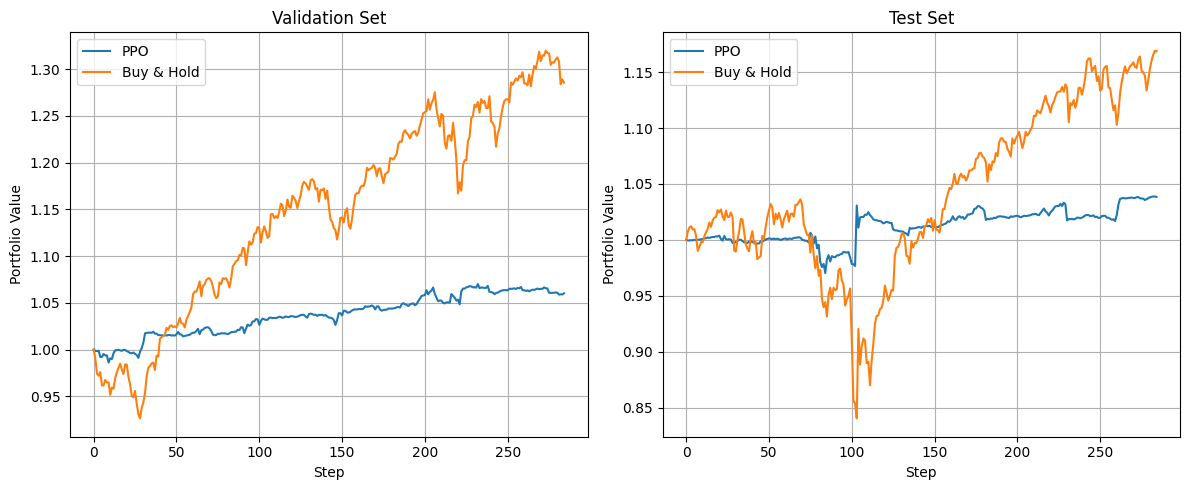

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

# ======================================
# Backtest function (stacked observations)
# ======================================
def run_backtest_stack(model, df_eval, env_kwargs):
    # Reuse the same env config + stacking as training
    eval_env = DummyVecEnv([
        lambda: Monitor(
            TradingGymEnv(
                df=df_eval,
                state_features=state_features,
                reward_clip=None,
                **env_kwargs
            )
        )
    ])
    if USE_FRAME_STACK:
        eval_env = VecFrameStack(eval_env, n_stack=N_STACK)

    obs = eval_env.reset()
    done = False
    portfolio_values = [1.0]
    last_info = None
    turnover_sum = 0.0
    exposure_sum = 0.0
    steps = 0
    positions = []
    trend_strengths = []
    weak_flags = []

    state = None
    episode_start = np.ones((eval_env.num_envs,), dtype=bool)

    while not done:
        action, state = model.predict(obs, state=state, episode_start=episode_start, deterministic=True)
        obs, reward, done, info = eval_env.step(action)
        episode_start = done
        done = bool(done[0])
        last_info = info[0]
        portfolio_values.append(last_info["portfolio_value"])

        pos = float(last_info.get("position", 0.0))
        positions.append(pos)
        trend_strengths.append(float(last_info.get("trend_strength", 0.0)))
        weak_flags.append(bool(last_info.get("weak_signal_flag", False)))

        turnover_sum += float(last_info.get("position_change", 0.0))
        exposure_sum += abs(pos)
        steps += 1

    avg_turnover = turnover_sum / max(1, steps)
    avg_abs_exposure = exposure_sum / max(1, steps)
    pos_arr = np.array(positions) if positions else np.array([0.0])
    weak_arr = np.array(weak_flags) if weak_flags else np.array([False])
    weak_avg_exposure = float(np.mean(np.abs(pos_arr[weak_arr]))) if weak_arr.any() else 0.0

    stats = {
        "mean_abs_exposure": avg_abs_exposure,
        "low_exposure_frac": float(np.mean(np.abs(pos_arr) < 0.2)),
        "high_exposure_frac": float(np.mean(np.abs(pos_arr) > 0.8)),
        "mean_position": float(np.mean(pos_arr)),
        "std_position": float(np.std(pos_arr)),
        "weak_signal_avg_exposure": weak_avg_exposure
    }

    return np.array(portfolio_values), last_info, avg_turnover, avg_abs_exposure, stats


# ======================================
# Run PPO backtest (best params)
# ======================================
val_equity, val_last_info, val_turnover, val_avg_exp, val_stats = run_backtest_stack(model, df_us_val, best_env_kwargs)
test_equity, test_last_info, test_turnover, test_avg_exp, test_stats = run_backtest_stack(model, df_us_test, best_env_kwargs)

print("Validation final value:", val_equity[-1])
print("Test final value:", test_equity[-1])


# ======================================
# Buy & Hold baseline
# ======================================
def buy_hold_curve(df):
    returns = df["raw_return_1d"].values
    equity = [1.0]
    for r in returns:
        equity.append(equity[-1] * (1 + r))
    return np.array(equity)


bh_val = buy_hold_curve(df_us_val)
bh_test = buy_hold_curve(df_us_test)


# ======================================
# Plot comparison
# ======================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(val_equity, label="PPO")
plt.plot(bh_val[:len(val_equity)], label="Buy & Hold")
plt.title("Validation Set")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_equity, label="PPO")
plt.plot(bh_test[:len(test_equity)], label="Buy & Hold")
plt.title("Test Set")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### JSON Signal Output (Single Market)

In [8]:
import numpy as np
import pandas as pd

# ======================================
# Performance metrics
# ======================================

def performance_metrics(equity_curve, turnover=None, avg_abs_exposure=None):

    returns = np.diff(equity_curve) / equity_curve[:-1]

    total_return = equity_curve[-1] - 1

    volatility = np.std(returns)

    sharpe = np.mean(returns) / (volatility + 1e-8)

    downside = returns[returns < 0]
    downside_std = np.std(downside) if len(downside) > 0 else 0.0
    sortino = np.mean(returns) / (downside_std + 1e-8)

    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (running_max - equity_curve) / running_max
    max_dd = np.max(drawdown)
    calmar = total_return / (max_dd + 1e-8)

    metrics = {
        "Total Return": total_return,
        "Volatility": volatility,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Calmar Ratio": calmar,
        "Max Drawdown": max_dd
    }

    # Optional diagnostics
    if turnover is not None:
        metrics["Turnover"] = float(turnover)
    if avg_abs_exposure is not None:
        metrics["Avg Abs Exposure"] = float(avg_abs_exposure)

    return metrics


# ======================================
# Compute metrics
# ======================================

ppo_val_metrics = performance_metrics(val_equity, val_turnover, val_avg_exp)
ppo_test_metrics = performance_metrics(test_equity, test_turnover, test_avg_exp)

bh_val_metrics = performance_metrics(bh_val[:len(val_equity)])
bh_test_metrics = performance_metrics(bh_test[:len(test_equity)])


# ======================================
# Create comparison table
# ======================================

results = pd.DataFrame({
    
    "PPO Validation": ppo_val_metrics,
    "BuyHold Validation": bh_val_metrics,
    
    "PPO Test": ppo_test_metrics,
    "BuyHold Test": bh_test_metrics
    
})

print("\nPerformance Comparison")
print(results.round(4))

print("\nExposure Diagnostics (US)")
print({
    "val_mean_abs_exposure": val_stats.get("mean_abs_exposure", None),
    "val_low_exposure_frac": val_stats.get("low_exposure_frac", None),
    "val_high_exposure_frac": val_stats.get("high_exposure_frac", None),
    "val_weak_signal_avg_exposure": val_stats.get("weak_signal_avg_exposure", None),
    "test_mean_abs_exposure": test_stats.get("mean_abs_exposure", None),
    "test_low_exposure_frac": test_stats.get("low_exposure_frac", None),
    "test_high_exposure_frac": test_stats.get("high_exposure_frac", None),
    "test_weak_signal_avg_exposure": test_stats.get("weak_signal_avg_exposure", None)
})

# JSON-style advisor signal output (single market)
# NOTE: future integration point for Advisor Bot / MCP / Clawbot layer
ma_gap_raw = float(df_us_test["MA_gap_raw"].iloc[-1])
trend_strength_raw = float(df_us_test["trend_strength_raw"].iloc[-1])
regime_vol_raw = float(df_us_test["regime_volatility_raw"].iloc[-1])
recent_drawdown = float(df_us_test["recent_drawdown"].iloc[-1])
trend_persistence = float(df_us_test["trend_persistence"].iloc[-1])
market_id = int(df_us_test["market_id"].iloc[-1])

signal_strength_raw = abs(ma_gap_raw) / (abs(regime_vol_raw) + 1e-6)
signal_strength = float(np.clip(signal_strength_raw / 10.0, 0.0, 1.0))

strong_trend = (abs(trend_strength_raw) > 0.01) or (abs(ma_gap_raw) > 0.005)
elevated_vol = regime_vol_raw > 0.012
stressed_dd = recent_drawdown > 0.6
if elevated_vol or stressed_dd:
    regime = "RISK_OFF"
elif strong_trend and regime_vol_raw < 0.015:
    regime = "TREND"
else:
    regime = "RANGE"

risk_level = "HIGH" if (regime_vol_raw > 0.015 or recent_drawdown > 0.6) else (
    "MEDIUM" if (regime_vol_raw > 0.01 or recent_drawdown > 0.25) else "LOW"
)

base_confidence = float(
    np.clip((ppo_val_metrics["Sharpe Ratio"] - ppo_val_metrics["Max Drawdown"]) / 3.0, 0.0, 1.0)
)
confidence = float(np.clip(0.6 * base_confidence + 0.4 * signal_strength, 0.0, 1.0))
if regime == "RISK_OFF":
    confidence *= 0.6

target_exposure = float(test_last_info["target_position"]) if test_last_info is not None else 0.0
effective_exposure = float(test_last_info.get("effective_position", test_last_info.get("position", 0.0))) if test_last_info is not None else 0.0
prev_effective_exposure = effective_exposure
try:
    if "test_positions" in globals() and len(test_positions) > 1:
        prev_effective_exposure = float(test_positions[-2])
except Exception:
    prev_effective_exposure = effective_exposure

risk_multiplier = 1.0
if regime == "RISK_OFF":
    risk_multiplier = 0.3 if (regime_vol_raw > 0.02 or recent_drawdown > 0.8) else 0.5
if risk_level == "HIGH":
    risk_multiplier = min(risk_multiplier, 0.5)

recommended_exposure = float(np.clip(effective_exposure * risk_multiplier, -1.0, 1.0))
prev_recommended = float(np.clip(prev_effective_exposure * risk_multiplier, -1.0, 1.0))

if abs(recommended_exposure) < 0.05:
    action_intent = "FLAT" if abs(prev_recommended) < 0.05 else "EXIT"
elif recommended_exposure > 0:
    if prev_recommended <= 0.05:
        action_intent = "ENTER_LONG"
    elif recommended_exposure - prev_recommended > 0.05:
        action_intent = "ENTER_LONG"
    elif prev_recommended - recommended_exposure > 0.05:
        action_intent = "REDUCE"
    else:
        action_intent = "HOLD"
else:
    if prev_recommended >= -0.05:
        action_intent = "ENTER_SHORT"
    elif recommended_exposure - prev_recommended < -0.05:
        action_intent = "ENTER_SHORT"
    elif prev_recommended - recommended_exposure < -0.05:
        action_intent = "REDUCE"
    else:
        action_intent = "HOLD"

position_size = float(np.clip(abs(recommended_exposure), 0.0, 1.0))
holding_horizon = "LONG" if regime == "TREND" else ("SHORT" if regime == "RISK_OFF" else "MEDIUM")

reason_codes = []
if signal_strength < 0.2:
    reason_codes.append("WEAK_SIGNAL")
if signal_strength > 0.5 and regime == "TREND":
    reason_codes.append("TREND_CONFIRMED")
if recent_drawdown < 0.1:
    reason_codes.append("LOW_DRAWDOWN")
if regime == "RISK_OFF":
    reason_codes.append("RISK_OFF")
if risk_multiplier < 1.0 or risk_level == "HIGH":
    reason_codes.append("REDUCE_RISK")

signal = {
    "market": "US",
    "regime": regime,
    "action_intent": action_intent,
    "position_size": position_size,
    "effective_exposure": recommended_exposure,
    "confidence": confidence,
    "risk_level": risk_level,
    "holding_horizon": holding_horizon,
    "reason_codes": reason_codes,
    "evidence": {
        "signal_strength_raw": float(signal_strength_raw),
        "recent_drawdown": float(recent_drawdown),
        "avg_abs_exposure": float(ppo_test_metrics.get("Avg Abs Exposure", 0.0)),
        "persistence_detected": bool(trend_persistence > 0.5),
        "market_id": market_id
    },
    "signal": "LONG" if recommended_exposure > 0.1 else ("SHORT" if recommended_exposure < -0.1 else "FLAT"),
    "target_exposure": target_exposure,
    "metrics": {
        "total_return": float(ppo_test_metrics["Total Return"]),
        "sharpe": float(ppo_test_metrics["Sharpe Ratio"]),
        "max_drawdown": float(ppo_test_metrics["Max Drawdown"]),
        "turnover": float(ppo_test_metrics.get("Turnover", 0.0)),
        "avg_abs_exposure": float(ppo_test_metrics.get("Avg Abs Exposure", 0.0))
    },
    "features": {
        "MA_gap_raw": ma_gap_raw,
        "trend_strength_raw": trend_strength_raw,
        "regime_volatility_raw": float(regime_vol_raw),
        "recent_drawdown": float(recent_drawdown),
        "trend_persistence": float(trend_persistence),
        "market_id": market_id
    }
}

print("\nJSON Signal (US)")
print(signal)


# ======================================
# Final portfolio values
# ======================================

print("\nFinal Portfolio Values")

print("PPO Validation:", val_equity[-1])
print("BuyHold Validation:", bh_val[len(val_equity)-1])

print("PPO Test:", test_equity[-1])
print("BuyHold Test:", bh_test[len(test_equity)-1])


Performance Comparison
                  PPO Validation  BuyHold Validation  PPO Test  BuyHold Test
Total Return              0.0603              0.2855    0.0384        0.1688
Volatility                0.0023              0.0078    0.0043        0.0114
Sharpe Ratio              0.0906              0.1168    0.0331        0.0539
Sortino Ratio             0.1279              0.1607    0.0501        0.0670
Calmar Ratio              3.5742              3.3647    1.0732        0.8931
Max Drawdown              0.0169              0.0849    0.0358        0.1890
Turnover                  0.0467                 NaN    0.0340           NaN
Avg Abs Exposure          0.2401                 NaN    0.1953           NaN

Exposure Diagnostics (US)
{'val_mean_abs_exposure': 0.24008240444244647, 'val_low_exposure_frac': 0.5845070422535211, 'val_high_exposure_frac': 0.0, 'val_weak_signal_avg_exposure': 0.09879417229418784, 'test_mean_abs_exposure': 0.19528635776024633, 'test_low_exposure_frac': 0.74647

In [9]:
import numpy as np
import pandas as pd

# ======================================
# Performance metrics
# ======================================

def compute_metrics(equity_curve):

    returns = np.diff(equity_curve) / equity_curve[:-1]

    total_return = equity_curve[-1] - 1

    volatility = np.std(returns) * np.sqrt(252)

    sharpe = np.mean(returns) / (np.std(returns) + 1e-8) * np.sqrt(252)

    running_max = np.maximum.accumulate(equity_curve)

    drawdown = (running_max - equity_curve) / running_max

    max_drawdown = np.max(drawdown)

    return {
        "Total Return": total_return,
        "Volatility": volatility,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    }


# ======================================
# Compute metrics
# ======================================

ppo_val_metrics = compute_metrics(val_equity)
ppo_test_metrics = compute_metrics(test_equity)

bh_val_metrics = compute_metrics(bh_val[:len(val_equity)])
bh_test_metrics = compute_metrics(bh_test[:len(test_equity)])


# ======================================
# Results table
# ======================================

results = pd.DataFrame({

    "PPO Validation": ppo_val_metrics,
    "BuyHold Validation": bh_val_metrics,

    "PPO Test": ppo_test_metrics,
    "BuyHold Test": bh_test_metrics

})

print("\nPerformance Comparison")
print(results.round(4))


# ======================================
# Final portfolio values
# ======================================

print("\nFinal Portfolio Values")

print("PPO Validation:", val_equity[-1])
print("BuyHold Validation:", bh_val[len(val_equity)-1])

print("PPO Test:", test_equity[-1])
print("BuyHold Test:", bh_test[len(test_equity)-1])


Performance Comparison
              PPO Validation  BuyHold Validation  PPO Test  BuyHold Test
Total Return          0.0603              0.2855    0.0384        0.1688
Volatility            0.0366              0.1245    0.0681        0.1807
Sharpe Ratio          1.4382              1.8535    0.5252        0.8561
Max Drawdown          0.0169              0.0849    0.0358        0.1890

Final Portfolio Values
PPO Validation: 1.0602507764799243
BuyHold Validation: 1.2854981919986466
PPO Test: 1.038441682563594
BuyHold Test: 1.1688131460994517


## Five-Market Evaluation + Global Option

### Local vs Global Comparison

### JSON Signal Output (Multi-Market)

In [10]:
# Duplicate summary removed; see Performance Comparison above.

In [11]:
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import random
import torch

# ======================================
# Reproducibility
# ======================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# Temporal window (stacked observations)
DEV_MODE = True  # True for faster experiments
N_STACK_DEV = 10
N_STACK_FULL = 20
N_STACK = N_STACK_DEV if DEV_MODE else N_STACK_FULL

# LSTM policy toggle
USE_LSTM = True
# NOTE: when using LSTM, do not stack frames (sequence handled by LSTM)
USE_FRAME_STACK = not USE_LSTM

# Reward mode: "new" or "baseline"
REWARD_MODE = "new"

# ======================================
# Markets
# ======================================
markets = ["US", "UK", "CN", "HK", "SG"]

# Validation-based reward hyperparameter grids (coarse -> refine)
COARSE_GRID = {
    "transaction_cost": [0.001],
    "lambda_turnover": [0.0005],
    "reward_return_weight": [3.0],
    "low_signal_threshold": [0.20, 0.25],
    "high_signal_threshold": [0.50, 0.60],
    "low_signal_flat_bonus": [0.05],
    "low_signal_exposure_penalty": [0.03, 0.05],
    "mid_signal_exposure_penalty": [0.01],
    "high_signal_alignment_reward": [0.08],
    "high_signal_wrong_way_penalty": [0.10],
    "extreme_position_penalty": [0.01],
    "persistence_lookback": [4],
    "trend_persistence_bonus": [0.02],
    "mid_signal_max_abs_position": [0.65]
}

REFINE_GRID = COARSE_GRID

COARSE_TIMESTEPS = 50000
REFINE_TIMESTEPS = 100000

EVAL_INTERVAL = 2000
PATIENCE = 2
TOP_K = 1

USE_MULTI_SEED = False
REFINE_SEEDS = [SEED]

USE_INACTIVITY_PENALTY = False
INACTIVITY_PENALTY = 0.0001
INACTIVITY_WINDOW = 20

USE_RISK_NORMALIZED_EXPOSURE = False
VOLATILITY_SCALE = 1.0

# DEV speed-up overrides (keep minimal search for quick iterations)
if DEV_MODE:
    COARSE_GRID = {
        "transaction_cost": [0.001],
        "lambda_turnover": [0.0005],
        "reward_return_weight": [3.0],
        "low_signal_threshold": [0.20],
        "high_signal_threshold": [0.50],
        "low_signal_flat_bonus": [0.05],
        "low_signal_exposure_penalty": [0.03],
        "mid_signal_exposure_penalty": [0.01],
        "high_signal_alignment_reward": [0.08],
        "high_signal_wrong_way_penalty": [0.10],
        "extreme_position_penalty": [0.01],
        "persistence_lookback": [4],
        "trend_persistence_bonus": [0.02],
        "mid_signal_max_abs_position": [0.65]
    }
REFINE_GRID = COARSE_GRID

# Controlled-aggressive policy (kept separate from stable selective)
CONTROLLED_AGGRESSIVE_PARAMS = {
    "reward_return_weight": 4.2,
    "high_signal_threshold": 0.36,
    "mid_signal_max_abs_position": 0.90,
    "high_signal_alignment_reward": 0.16,
    "trend_persistence_bonus": 0.035
}
ENABLE_AGGRESSIVE_POLICY = True
AGGRESSIVE_TIMESTEPS = 30000 if DEV_MODE else 120000

COARSE_TIMESTEPS = 50000
REFINE_TIMESTEPS = 100000
TOP_K = 1
USE_MULTI_SEED = False
EVAL_INTERVAL = 2000
PATIENCE = 2

# Optional global training mode
USE_GLOBAL_TRAINING = True

all_results = []
all_equity_curves = {}
all_signals = []
advisor_rows = []
policy_compare_rows = []

# exposure diagnostics
local_test_positions = {}
market_splits = {}
market_splits_raw = {}
cache = {}

# Use the same feature setting as previous cells
base_features = [
    "return_1d",
    "return_5d",
    "return_10d",
    "MA_gap",
    "volatility_10",
    "volume_change",
    "RSI_14",
    "MACD"
]

regime_features = [
    "trend_strength",
    "regime_volatility",
    "bull_flag"
]

extra_features = [
    "downside_volatility",
    "rolling_downside_mean",
    "rolling_skewness",
    "trend_persistence",
    "recent_drawdown",
    "ma_slope",
    "bear_market_flag"
]

id_features = [
    "market_id"
]

state_features = base_features + regime_features + extra_features + id_features

# IMPORTANT:
# raw_return_1d is ONLY for reward / backtesting
# regime_volatility_raw is ONLY for reward penalty
# market_id is discrete and must never be scaled
scale_cols = base_features + regime_features + extra_features

# ======================================
# Utility functions
# ======================================
def linear_schedule(initial_value, final_value):
    def schedule(progress_remaining):
        return final_value + (initial_value - final_value) * progress_remaining
    return schedule


POLICY_NAME = "MlpLstmPolicy" if USE_LSTM else "MlpPolicy"
ALGO_CLASS = RecurrentPPO if USE_LSTM else PPO


def time_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    df_train = df.iloc[:train_end].copy()
    df_val = df.iloc[train_end:val_end].copy()
    df_test = df.iloc[val_end:].copy()

    return df_train, df_val, df_test


def run_backtest_single_env(model, df_eval, state_features, env_kwargs):
    # Use stacked observations for temporal context (same as training)
    eval_env = DummyVecEnv([
        lambda: Monitor(
            TradingGymEnv(
                df=df_eval,
                state_features=state_features,
                reward_clip=None,
                **env_kwargs
            )
        )
    ])
    if USE_FRAME_STACK:
        eval_env = VecFrameStack(eval_env, n_stack=N_STACK)

    obs = eval_env.reset()
    done = False

    portfolio_values = [1.0]
    last_info = None
    turnover_sum = 0.0
    exposure_sum = 0.0
    steps = 0
    positions = []
    trend_strengths = []
    weak_flags = []

    state = None
    episode_start = np.ones((eval_env.num_envs,), dtype=bool)

    while not done:
        action, state = model.predict(obs, state=state, episode_start=episode_start, deterministic=True)
        obs, reward, done, info = eval_env.step(action)
        episode_start = done
        done = bool(done[0])
        last_info = info[0]
        portfolio_values.append(last_info["portfolio_value"])

        pos = float(last_info.get("position", 0.0))
        positions.append(pos)
        trend_strengths.append(float(last_info.get("trend_strength", 0.0)))
        weak_flags.append(bool(last_info.get("weak_signal_flag", False)))

        turnover_sum += float(last_info.get("position_change", 0.0))
        exposure_sum += abs(pos)
        steps += 1

    avg_turnover = turnover_sum / max(1, steps)
    avg_abs_exposure = exposure_sum / max(1, steps)
    pos_arr = np.array(positions) if positions else np.array([0.0])
    weak_arr = np.array(weak_flags) if weak_flags else np.array([False])
    weak_avg_exposure = float(np.mean(np.abs(pos_arr[weak_arr]))) if weak_arr.any() else 0.0

    stats = {
        "mean_abs_exposure": avg_abs_exposure,
        "low_exposure_frac": float(np.mean(np.abs(pos_arr) < 0.2)),
        "high_exposure_frac": float(np.mean(np.abs(pos_arr) > 0.8)),
        "mean_position": float(np.mean(pos_arr)),
        "std_position": float(np.std(pos_arr)),
        "weak_signal_avg_exposure": weak_avg_exposure
    }

    return np.array(portfolio_values), last_info, avg_turnover, avg_abs_exposure, stats, np.array(positions)


def buy_hold_curve(df_eval):
    returns = df_eval["raw_return_1d"].values

    equity = [1.0]
    for r in returns:
        equity.append(equity[-1] * (1 + r))

    return np.array(equity)


def compute_metrics(equity_curve, turnover=None, avg_abs_exposure=None):
    equity_curve = np.array(equity_curve)

    returns = np.diff(equity_curve) / equity_curve[:-1]

    total_return = equity_curve[-1] - 1
    volatility = np.std(returns) * np.sqrt(252)
    sharpe = np.mean(returns) / (np.std(returns) + 1e-8) * np.sqrt(252)

    downside = returns[returns < 0]
    downside_std = np.std(downside) * np.sqrt(252) if len(downside) > 0 else 0.0
    sortino = np.mean(returns) / (downside_std + 1e-8) * np.sqrt(252)

    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (running_max - equity_curve) / running_max
    max_drawdown = np.max(drawdown)
    calmar = total_return / (max_drawdown + 1e-8)

    return total_return, volatility, sharpe, max_drawdown, calmar, sortino, turnover, avg_abs_exposure


def validation_score_local(metrics):
    return metrics["Sharpe"] - 0.4 * metrics["Max Drawdown"] - 0.1 * metrics["Turnover"]


def global_validation_score(model, global_scaled_splits, env_kwargs):
    scores = []
    for m in markets:
        df_val_g, _ = global_scaled_splits[m]
        val_curve, _, val_turnover, val_avg_exp, _, _ = run_backtest_single_env(
            model, df_val_g, state_features, env_kwargs
        )
        _, _, val_sharpe, val_mdd, _, _, val_turnover, val_avg_exp = compute_metrics(
            val_curve, val_turnover, val_avg_exp
        )
        metrics = {
            "Sharpe": float(val_sharpe),
            "Max Drawdown": float(val_mdd),
            "Turnover": float(val_turnover),
            "Avg Abs Exposure": float(val_avg_exp)
        }
        scores.append(validation_score_local(metrics))

    return float(np.mean(scores))


def make_global_train_env(train_split_dict, env_kwargs):
    env_fns = []
    for _, df_train in train_split_dict.items():
        env_fns.append(
            lambda df=df_train: Monitor(
                TradingGymEnv(
                    df=df,
                    state_features=state_features,
                    reward_clip=None,
                    **env_kwargs
                )
            )
        )
    env = DummyVecEnv(env_fns)
    if USE_FRAME_STACK:
        env = VecFrameStack(env, n_stack=N_STACK)
    return env


def train_global_with_early_stopping(train_split_dict, global_scaled_splits, params, timesteps, seed, stage, cache):
    env_kwargs = build_env_kwargs(params)
    key = cache_key_from(params, timesteps, seed, stage + "_global")
    cache_path = os.path.join("ppo_cache_models", f"{key}.zip")

    if key in cache and os.path.exists(cache_path):
        cached = cache[key]
        model = ALGO_CLASS.load(cache_path, env=make_global_train_env(train_split_dict, env_kwargs))
        return model, cached["score"], env_kwargs

    os.makedirs("ppo_cache_models", exist_ok=True)
    train_env = make_global_train_env(train_split_dict, env_kwargs)

    model = ALGO_CLASS(
        policy=POLICY_NAME,
        env=train_env,
        verbose=0,
        learning_rate=linear_schedule(3e-4, 1e-5),
        n_steps=256,
        batch_size=64,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        vf_coef=0.5,
        max_grad_norm=0.5,
        seed=seed
    )

    best_score = -np.inf
    steps = 0
    no_improve = 0

    while steps < timesteps:
        step_size = min(EVAL_INTERVAL, timesteps - steps)
        model.learn(step_size, reset_num_timesteps=False)
        steps += step_size

        avg_score = global_validation_score(model, global_scaled_splits, env_kwargs)

        if avg_score > best_score + 1e-6:
            best_score = avg_score
            no_improve = 0
            model.save(cache_path)
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                break

    model = ALGO_CLASS.load(cache_path, env=train_env)
    cache[key] = {"score": best_score}
    return model, best_score, env_kwargs


# ======================================
# Meta regime agent + advisor signal
# ======================================

def select_regime(feature_snapshot):
    ma_gap_raw = float(feature_snapshot.get("MA_gap_raw", 0.0))
    trend_strength_raw = float(feature_snapshot.get("trend_strength_raw", feature_snapshot.get("trend_strength", 0.0)))
    regime_vol_raw = float(feature_snapshot.get("regime_volatility_raw", 0.0))
    recent_drawdown = float(feature_snapshot.get("recent_drawdown", 0.0))

    strong_trend = (abs(trend_strength_raw) > 0.01) or (abs(ma_gap_raw) > 0.005)
    elevated_vol = regime_vol_raw > 0.012
    stressed_dd = recent_drawdown > 0.6

    if elevated_vol or stressed_dd:
        return "RISK_OFF"
    if strong_trend and regime_vol_raw < 0.015:
        return "TREND"
    return "RANGE"


def map_risk_level(regime_volatility_raw, recent_drawdown):
    if regime_volatility_raw > 0.015 or recent_drawdown > 0.6:
        return "HIGH"
    if regime_volatility_raw > 0.01 or recent_drawdown > 0.25:
        return "MEDIUM"
    return "LOW"


def infer_action_intent(prev_exposure, current_exposure):
    eps = 0.05
    if abs(current_exposure) < eps:
        return "FLAT" if abs(prev_exposure) < eps else "EXIT"

    if current_exposure > 0:
        if prev_exposure <= eps:
            return "ENTER_LONG"
        if current_exposure - prev_exposure > eps:
            return "ENTER_LONG"
        if prev_exposure - current_exposure > eps:
            return "REDUCE"
        return "HOLD"

    if prev_exposure >= -eps:
        return "ENTER_SHORT"
    if current_exposure - prev_exposure < -eps:
        return "ENTER_SHORT"
    if prev_exposure - current_exposure < -eps:
        return "REDUCE"
    return "HOLD"


def build_advisor_signal(
    market,
    target_exposure,
    effective_exposure,
    prev_effective_exposure,
    val_metrics,
    test_metrics,
    feature_snapshot,
    policy_mode
):
    ma_gap_raw = float(feature_snapshot.get("MA_gap_raw", 0.0))
    trend_strength_raw = float(feature_snapshot.get("trend_strength_raw", feature_snapshot.get("trend_strength", 0.0)))
    regime_vol_raw = float(feature_snapshot.get("regime_volatility_raw", 0.0))
    recent_drawdown = float(feature_snapshot.get("recent_drawdown", 0.0))
    trend_persistence = float(feature_snapshot.get("trend_persistence", 0.0))
    market_id = int(feature_snapshot.get("market_id", -1))

    signal_strength_raw = abs(ma_gap_raw) / (abs(regime_vol_raw) + 1e-6)
    signal_strength = float(np.clip(signal_strength_raw / 10.0, 0.0, 1.0))

    regime = select_regime(feature_snapshot)
    risk_level = map_risk_level(regime_vol_raw, recent_drawdown)

    base_confidence = float(
        np.clip((val_metrics["Sharpe"] - val_metrics["Max Drawdown"]) / 3.0, 0.0, 1.0)
    )
    confidence = float(np.clip(0.6 * base_confidence + 0.4 * signal_strength, 0.0, 1.0))
    if regime == "RISK_OFF":
        confidence *= 0.6

    risk_multiplier = 1.0
    if regime == "RISK_OFF":
        risk_multiplier = 0.3 if (regime_vol_raw > 0.02 or recent_drawdown > 0.8) else 0.5
    if risk_level == "HIGH":
        risk_multiplier = min(risk_multiplier, 0.5)

    recommended_exposure = float(np.clip(effective_exposure * risk_multiplier, -1.0, 1.0))
    prev_recommended = float(np.clip(prev_effective_exposure * risk_multiplier, -1.0, 1.0))

    action_intent = infer_action_intent(prev_recommended, recommended_exposure)
    if regime == "RISK_OFF" and abs(recommended_exposure) < 0.05:
        action_intent = "FLAT"

    position_size = float(np.clip(abs(recommended_exposure), 0.0, 1.0))
    holding_horizon = "LONG" if regime == "TREND" else ("SHORT" if regime == "RISK_OFF" else "MEDIUM")

    reason_codes = []
    if signal_strength < 0.2:
        reason_codes.append("WEAK_SIGNAL")
    if signal_strength > 0.5 and regime == "TREND":
        reason_codes.append("TREND_CONFIRMED")
    if recent_drawdown < 0.1:
        reason_codes.append("LOW_DRAWDOWN")
    if regime == "RISK_OFF":
        reason_codes.append("RISK_OFF")
    if risk_multiplier < 1.0 or risk_level == "HIGH":
        reason_codes.append("REDUCE_RISK")
    if policy_mode == "aggressive":
        reason_codes.append("POLICY_AGGRESSIVE")
    else:
        reason_codes.append("POLICY_CONSERVATIVE")

    signal = "LONG" if recommended_exposure > 0.1 else ("SHORT" if recommended_exposure < -0.1 else "FLAT")

    return {
        "market": market,
        "regime": regime,
        "action_intent": action_intent,
        "position_size": position_size,
        "effective_exposure": recommended_exposure,
        "confidence": confidence,
        "risk_level": risk_level,
        "holding_horizon": holding_horizon,
        "reason_codes": reason_codes,
        "evidence": {
            "signal_strength_raw": float(signal_strength_raw),
            "recent_drawdown": float(recent_drawdown),
            "avg_abs_exposure": float(test_metrics["Avg Abs Exposure"]),
            "persistence_detected": bool(trend_persistence > 0.5),
            "market_id": market_id
        },
        "signal": signal,
        "target_exposure": float(target_exposure),
        "metrics": {
            "total_return": float(test_metrics["Total Return"]),
            "sharpe": float(test_metrics["Sharpe"]),
            "max_drawdown": float(test_metrics["Max Drawdown"]),
            "turnover": float(test_metrics["Turnover"]),
            "avg_abs_exposure": float(test_metrics["Avg Abs Exposure"])
        },
        "features": {
            "MA_gap_raw": ma_gap_raw,
            "trend_strength_raw": trend_strength_raw,
            "regime_volatility_raw": float(regime_vol_raw),
            "recent_drawdown": float(recent_drawdown),
            "trend_persistence": float(trend_persistence),
            "market_id": market_id
        }
    }


def build_signal(
    market,
    target_exposure,
    effective_exposure,
    prev_effective_exposure,
    val_metrics,
    test_metrics,
    feature_snapshot,
    policy_mode
):
    return build_advisor_signal(
        market,
        target_exposure,
        effective_exposure,
        prev_effective_exposure,
        val_metrics,
        test_metrics,
        feature_snapshot,
        policy_mode
    )


# ======================================
# Market-by-market training and testing
# ======================================
for market_name in markets:
    print(f"\n========== Training PPO for {market_name} ==========")

    # Prepare market-specific data
    df_market = (
        df_all[df_all["market"] == market_name]
        .sort_values("date")
        .reset_index(drop=True)
        .copy()
    )

    # Clean data
    df_market = df_market.replace([np.inf, -np.inf], np.nan)
    df_market = df_market.dropna(subset=state_features).reset_index(drop=True)

    # Train / Val / Test split BEFORE scaling
    df_train, df_val, df_test = time_split(df_market, train_ratio=0.6, val_ratio=0.2)

    # Store raw splits for optional global training
    market_splits_raw[market_name] = (df_train.copy(), df_val.copy(), df_test.copy())

    print(f"{market_name} split sizes -> Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

    # Scale train only, then transform val / test
    scaler = StandardScaler()
    df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols])
    df_val[scale_cols] = scaler.transform(df_val[scale_cols])
    df_test[scale_cols] = scaler.transform(df_test[scale_cols])

    # Clip extreme values for stability
    df_train[scale_cols] = df_train[scale_cols].clip(-5, 5)
    df_val[scale_cols] = df_val[scale_cols].clip(-5, 5)
    df_test[scale_cols] = df_test[scale_cols].clip(-5, 5)

    # Store split for optional global training
    market_splits[market_name] = (df_train.copy(), df_val.copy(), df_test.copy())

    # Hyperparameter search (coarse -> refine)
    coarse_configs = expand_grid(COARSE_GRID)
    coarse_results = []

    for params in coarse_configs:
        model, metrics, score, env_kwargs, early_stopped = train_with_early_stopping(
            df_train,
            df_val,
            params,
            timesteps=COARSE_TIMESTEPS,
            seed=SEED,
            stage=f"{market_name}_coarse",
            cache=cache
        )
        coarse_results.append({
            "params": params,
            "score": score,
            "sharpe": metrics["Sharpe"],
            "mdd": metrics["Max Drawdown"],
            "turnover": metrics["Turnover"],
            "avg_abs_exposure": metrics["Avg Abs Exposure"]
        })

    coarse_df = pd.DataFrame(coarse_results).sort_values("score", ascending=False)
    refine_candidates = coarse_df.head(TOP_K)["params"].tolist()

    best_score = -np.inf
    best_model = None
    best_params = None

    for params in refine_candidates:
        seed_list = REFINE_SEEDS if USE_MULTI_SEED else [SEED]
        scores = []
        best_seed_score = -np.inf
        best_seed_model = None

        for seed in seed_list:
            model, metrics, score, env_kwargs, early_stopped = train_with_early_stopping(
                df_train,
                df_val,
                params,
                timesteps=REFINE_TIMESTEPS,
                seed=seed,
                stage=f"{market_name}_refine",
                cache=cache
            )
            scores.append(score)
            if score > best_seed_score:
                best_seed_score = score
                best_seed_model = model

        avg_score = float(np.mean(scores))
        if avg_score > best_score:
            best_score = avg_score
            best_model = best_seed_model
            best_params = params

    print("Best params:", best_params)
    print("Best score:", best_score)

    # Use best model for downstream evaluation
    model = best_model
    best_env_kwargs = build_env_kwargs(best_params)

    # Save model
    model.save(f"ppo_trading_model_{market_name}")

    # Optional controlled-aggressive policy (kept separate)
    aggressive_model = None
    aggressive_env_kwargs = None
    if ENABLE_AGGRESSIVE_POLICY:
        aggressive_params = dict(best_params)
        aggressive_params.update(CONTROLLED_AGGRESSIVE_PARAMS)
        aggressive_model, aggressive_metrics, aggressive_score, aggressive_env_kwargs, _ = train_with_early_stopping(
            df_train,
            df_val,
            aggressive_params,
            timesteps=AGGRESSIVE_TIMESTEPS,
            seed=SEED,
            stage=f"{market_name}_aggressive",
            cache=cache
        )

    # Validation backtest
    val_ppo_curve, val_last_info, val_turnover, val_avg_exp, val_stats, _ = run_backtest_single_env(
        model, df_val, state_features, best_env_kwargs
    )
    val_bh_curve = buy_hold_curve(df_val)

    # Test backtest
    test_ppo_curve, test_last_info, test_turnover, test_avg_exp, test_stats, test_positions = run_backtest_single_env(
        model, df_test, state_features, best_env_kwargs
    )
    test_bh_curve = buy_hold_curve(df_test)

    aggressive_val_metrics = None
    aggressive_test_metrics = None
    aggressive_test_last_info = None
    aggressive_test_positions = np.array([])

    if aggressive_model is not None and aggressive_env_kwargs is not None:
        aggressive_val_curve, _, aggressive_val_turnover, aggressive_val_avg_exp, aggressive_val_stats, _ = run_backtest_single_env(
            aggressive_model, df_val, state_features, aggressive_env_kwargs
        )
        aggressive_test_curve, aggressive_test_last_info, aggressive_test_turnover, aggressive_test_avg_exp, aggressive_test_stats, aggressive_test_positions = run_backtest_single_env(
            aggressive_model, df_test, state_features, aggressive_env_kwargs
        )

        aggressive_val_total, aggressive_val_vol, aggressive_val_sharpe, aggressive_val_mdd, aggressive_val_calmar, aggressive_val_sortino, aggressive_val_turnover, aggressive_val_avg_exp = compute_metrics(
            aggressive_val_curve, aggressive_val_turnover, aggressive_val_avg_exp
        )
        aggressive_test_total, aggressive_test_vol, aggressive_test_sharpe, aggressive_test_mdd, aggressive_test_calmar, aggressive_test_sortino, aggressive_test_turnover, aggressive_test_avg_exp = compute_metrics(
            aggressive_test_curve, aggressive_test_turnover, aggressive_test_avg_exp
        )

        aggressive_val_metrics = {
            "Sharpe": float(aggressive_val_sharpe),
            "Max Drawdown": float(aggressive_val_mdd),
            "Turnover": float(aggressive_val_turnover),
            "Avg Abs Exposure": float(aggressive_val_avg_exp)
        }
        aggressive_test_metrics = {
            "Total Return": float(aggressive_test_total),
            "Sharpe": float(aggressive_test_sharpe),
            "Max Drawdown": float(aggressive_test_mdd),
            "Turnover": float(aggressive_test_turnover),
            "Avg Abs Exposure": float(aggressive_test_avg_exp)
        }

    # Store TEST curves for final plotting
    all_equity_curves[market_name] = {
        "ppo": test_ppo_curve,
        "buy_hold": test_bh_curve[:len(test_ppo_curve)]
    }
    local_test_positions[market_name] = test_positions

    # Compute metrics
    val_ppo_total, val_ppo_vol, val_ppo_sharpe, val_ppo_mdd, val_ppo_calmar, val_ppo_sortino, val_ppo_turnover, val_ppo_avg_exp = compute_metrics(
        val_ppo_curve, val_turnover, val_avg_exp
    )
    val_bh_total, val_bh_vol, val_bh_sharpe, val_bh_mdd, val_bh_calmar, val_bh_sortino, _, _ = compute_metrics(
        val_bh_curve[:len(val_ppo_curve)]
    )

    test_ppo_total, test_ppo_vol, test_ppo_sharpe, test_ppo_mdd, test_ppo_calmar, test_ppo_sortino, test_ppo_turnover, test_ppo_avg_exp = compute_metrics(
        test_ppo_curve, test_turnover, test_avg_exp
    )
    test_bh_total, test_bh_vol, test_bh_sharpe, test_bh_mdd, test_bh_calmar, test_bh_sortino, _, _ = compute_metrics(
        test_bh_curve[:len(test_ppo_curve)]
    )

    # Build JSON-style advisor signal output (confidence from validation)
    target_exposure = float(test_last_info["target_position"]) if test_last_info is not None else 0.0
    effective_exposure = float(test_last_info.get("effective_position", test_last_info.get("position", 0.0))) if test_last_info is not None else 0.0
    prev_effective_exposure = float(test_positions[-2]) if len(test_positions) > 1 else (
        float(test_positions[-1]) if len(test_positions) > 0 else 0.0
    )

    aggressive_target_exposure = 0.0
    aggressive_effective_exposure = 0.0
    aggressive_prev_exposure = 0.0
    if aggressive_test_last_info is not None:
        aggressive_target_exposure = float(aggressive_test_last_info["target_position"])
        aggressive_effective_exposure = float(
            aggressive_test_last_info.get("effective_position", aggressive_test_last_info.get("position", 0.0))
        )
        aggressive_prev_exposure = float(aggressive_test_positions[-2]) if len(aggressive_test_positions) > 1 else (
            float(aggressive_test_positions[-1]) if len(aggressive_test_positions) > 0 else 0.0
        )

    val_metrics = {
        "Sharpe": float(val_ppo_sharpe),
        "Max Drawdown": float(val_ppo_mdd),
        "Turnover": float(val_ppo_turnover),
        "Avg Abs Exposure": float(val_ppo_avg_exp)
    }

    test_metrics = {
        "Total Return": float(test_ppo_total),
        "Sharpe": float(test_ppo_sharpe),
        "Max Drawdown": float(test_ppo_mdd),
        "Turnover": float(test_ppo_turnover),
        "Avg Abs Exposure": float(test_ppo_avg_exp)
    }

    feature_snapshot = {
        "MA_gap_raw": float(df_test["MA_gap_raw"].iloc[-1]),
        "trend_strength_raw": float(df_test["trend_strength_raw"].iloc[-1]),
        "regime_volatility_raw": float(df_test["regime_volatility_raw"].iloc[-1]),
        "recent_drawdown": float(df_test["recent_drawdown"].iloc[-1]),
        "trend_persistence": float(df_test["trend_persistence"].iloc[-1]),
        "market_id": int(df_test["market_id"].iloc[-1])
    }

    regime = select_regime(feature_snapshot)
    use_aggressive = regime == "TREND" and aggressive_test_metrics is not None
    policy_mode = "aggressive" if use_aggressive else "conservative"

    selected_target_exposure = aggressive_target_exposure if use_aggressive else target_exposure
    selected_effective_exposure = aggressive_effective_exposure if use_aggressive else effective_exposure
    selected_prev_exposure = aggressive_prev_exposure if use_aggressive else prev_effective_exposure
    selected_val_metrics = aggressive_val_metrics if use_aggressive else val_metrics
    selected_test_metrics = aggressive_test_metrics if use_aggressive else test_metrics

    signal = build_signal(
        market_name,
        selected_target_exposure,
        selected_effective_exposure,
        selected_prev_exposure,
        selected_val_metrics,
        selected_test_metrics,
        feature_snapshot,
        policy_mode
    )
    all_signals.append(signal)

    advisor_rows.append({
        "Market": market_name,
        "Regime": signal["regime"],
        "Action Intent": signal["action_intent"],
        "Position Size": signal["position_size"],
        "Confidence": signal["confidence"],
        "Risk Level": signal["risk_level"],
        "Total Return": signal["metrics"]["total_return"],
        "Sharpe Ratio": signal["metrics"]["sharpe"],
        "Max Drawdown": signal["metrics"]["max_drawdown"],
        "Avg Abs Exposure": signal["metrics"]["avg_abs_exposure"]
    })

    policy_compare_rows.append({
        "Market": market_name,
        "Policy": "Buy & Hold",
        "Total Return": float(test_bh_total),
        "Sharpe Ratio": float(test_bh_sharpe),
        "Max Drawdown": float(test_bh_mdd),
        "Avg Abs Exposure": float(test_stats.get("mean_abs_exposure", 0.0))
    })
    policy_compare_rows.append({
        "Market": market_name,
        "Policy": "Stable Selective",
        "Total Return": float(test_ppo_total),
        "Sharpe Ratio": float(test_ppo_sharpe),
        "Max Drawdown": float(test_ppo_mdd),
        "Avg Abs Exposure": float(test_ppo_avg_exp)
    })
    policy_compare_rows.append({
        "Market": market_name,
        "Policy": "Meta Switched",
        "Total Return": float(signal["metrics"]["total_return"]),
        "Sharpe Ratio": float(signal["metrics"]["sharpe"]),
        "Max Drawdown": float(signal["metrics"]["max_drawdown"]),
        "Avg Abs Exposure": float(signal["metrics"]["avg_abs_exposure"])
    })

    all_results.append({
        "Market": market_name,

        "PPO Val Total Return": val_ppo_total,
        "BH Val Total Return": val_bh_total,
        "PPO Val Volatility": val_ppo_vol,
        "BH Val Volatility": val_bh_vol,
        "PPO Val Sharpe": val_ppo_sharpe,
        "BH Val Sharpe": val_bh_sharpe,
        "PPO Val Max Drawdown": val_ppo_mdd,
        "BH Val Max Drawdown": val_bh_mdd,
        "PPO Val Calmar": val_ppo_calmar,
        "BH Val Calmar": val_bh_calmar,
        "PPO Val Sortino": val_ppo_sortino,
        "BH Val Sortino": val_bh_sortino,
        "PPO Val Turnover": val_ppo_turnover,
        "PPO Val Avg Abs Exposure": val_ppo_avg_exp,
        "PPO Val Low Exposure Fraction": val_stats.get("low_exposure_frac", None),
        "PPO Val High Exposure Fraction": val_stats.get("high_exposure_frac", None),
        "PPO Val Weak-Signal Avg Exposure": val_stats.get("weak_signal_avg_exposure", None),
        "PPO Val Mean Position": val_stats.get("mean_position", None),
        "PPO Val Position Std": val_stats.get("std_position", None),

        "PPO Test Total Return": test_ppo_total,
        "BH Test Total Return": test_bh_total,
        "PPO Test Volatility": test_ppo_vol,
        "BH Test Volatility": test_bh_vol,
        "PPO Test Sharpe": test_ppo_sharpe,
        "BH Test Sharpe": test_bh_sharpe,
        "PPO Test Max Drawdown": test_ppo_mdd,
        "BH Test Max Drawdown": test_bh_mdd,
        "PPO Test Calmar": test_ppo_calmar,
        "BH Test Calmar": test_bh_calmar,
        "PPO Test Sortino": test_ppo_sortino,
        "BH Test Sortino": test_bh_sortino,
        "PPO Test Turnover": test_ppo_turnover,
        "PPO Test Avg Abs Exposure": test_ppo_avg_exp,
        "PPO Test Low Exposure Fraction": test_stats.get("low_exposure_frac", None),
        "PPO Test High Exposure Fraction": test_stats.get("high_exposure_frac", None),
        "PPO Test Weak-Signal Avg Exposure": test_stats.get("weak_signal_avg_exposure", None),
        "PPO Test Mean Position": test_stats.get("mean_position", None),
        "PPO Test Position Std": test_stats.get("std_position", None)
    })

print("\nAll markets training completed.")

# ======================================
# Optional global training mode
# ======================================
all_results_global = []
all_equity_curves_global = {}
all_signals_global = []

# exposure diagnostics
global_test_positions = {}

if USE_GLOBAL_TRAINING:
    print("\n========== Training GLOBAL PPO model ==========")

    # Concatenate raw TRAIN splits (scaler only; no mixed-market episodes)
    df_global_train = pd.concat([market_splits_raw[m][0] for m in markets], axis=0)
    df_global_train = df_global_train.sort_values(["date", "market"]).reset_index(drop=True)

    # Fit scaler on GLOBAL TRAIN only
    scaler_global = StandardScaler()
    df_global_train[scale_cols] = scaler_global.fit_transform(df_global_train[scale_cols])
    df_global_train[scale_cols] = df_global_train[scale_cols].clip(-5, 5)

    # Prepare scaled per-market TRAIN/VAL/TEST using global scaler
    global_train_splits = {}
    global_scaled_splits = {}
    for m in markets:
        df_train_g = market_splits_raw[m][0].copy()
        df_val_g = market_splits_raw[m][1].copy()
        df_test_g = market_splits_raw[m][2].copy()

        df_train_g[scale_cols] = scaler_global.transform(df_train_g[scale_cols])
        df_val_g[scale_cols] = scaler_global.transform(df_val_g[scale_cols])
        df_test_g[scale_cols] = scaler_global.transform(df_test_g[scale_cols])

        df_train_g[scale_cols] = df_train_g[scale_cols].clip(-5, 5)
        df_val_g[scale_cols] = df_val_g[scale_cols].clip(-5, 5)
        df_test_g[scale_cols] = df_test_g[scale_cols].clip(-5, 5)

        global_train_splits[m] = df_train_g
        global_scaled_splits[m] = (df_val_g, df_test_g)

    coarse_configs = expand_grid(COARSE_GRID)
    coarse_results = []

    for params in coarse_configs:
        model, score, env_kwargs = train_global_with_early_stopping(
            global_train_splits,
            global_scaled_splits,
            params,
            timesteps=COARSE_TIMESTEPS,
            seed=SEED,
            stage="global_coarse",
            cache=cache
        )
        coarse_results.append({"params": params, "score": score})

    coarse_df = pd.DataFrame(coarse_results).sort_values("score", ascending=False)
    refine_candidates = coarse_df.head(TOP_K)["params"].tolist()

    best_score = -np.inf
    best_model = None
    best_params = None
    best_env_kwargs = None

    for params in refine_candidates:
        seed_list = REFINE_SEEDS if USE_MULTI_SEED else [SEED]
        scores = []
        best_seed_score = -np.inf
        best_seed_model = None
        best_seed_env_kwargs = None

        for seed in seed_list:
            model, score, env_kwargs = train_global_with_early_stopping(
                global_train_splits,
                global_scaled_splits,
                params,
                timesteps=REFINE_TIMESTEPS,
                seed=seed,
                stage="global_refine",
                cache=cache
            )
            scores.append(score)
            if score > best_seed_score:
                best_seed_score = score
                best_seed_model = model
                best_seed_env_kwargs = env_kwargs

        avg_score = float(np.mean(scores))
        if avg_score > best_score:
            best_score = avg_score
            best_model = best_seed_model
            best_params = params
            best_env_kwargs = best_seed_env_kwargs

    print("Global best params:", best_params)
    print("Global best score:", best_score)

    # Evaluate global model per market (VAL/TEST)
    for m in markets:
        df_val_g, df_test_g = global_scaled_splits[m]

        val_curve, val_last_info, val_turnover, val_avg_exp, val_stats, _ = run_backtest_single_env(
            best_model, df_val_g, state_features, best_env_kwargs
        )
        test_curve, test_last_info, test_turnover, test_avg_exp, test_stats, test_positions = run_backtest_single_env(
            best_model, df_test_g, state_features, best_env_kwargs
        )

        val_total, val_vol, val_sharpe, val_mdd, val_calmar, val_sortino, val_turnover, val_avg_exp = compute_metrics(
            val_curve, val_turnover, val_avg_exp
        )
        test_total, test_vol, test_sharpe, test_mdd, test_calmar, test_sortino, test_turnover, test_avg_exp = compute_metrics(
            test_curve, test_turnover, test_avg_exp
        )

        all_equity_curves_global[m] = {
            "ppo": test_curve
        }
        global_test_positions[m] = test_positions

        all_results_global.append({
            "Market": m,
            "PPO Val Total Return": val_total,
            "PPO Val Volatility": val_vol,
            "PPO Val Sharpe": val_sharpe,
            "PPO Val Max Drawdown": val_mdd,
            "PPO Val Calmar": val_calmar,
            "PPO Val Sortino": val_sortino,
            "PPO Val Turnover": val_turnover,
            "PPO Val Avg Abs Exposure": val_avg_exp,
            "PPO Val Low Exposure Fraction": val_stats.get("low_exposure_frac", None),
            "PPO Val High Exposure Fraction": val_stats.get("high_exposure_frac", None),
            "PPO Val Weak-Signal Avg Exposure": val_stats.get("weak_signal_avg_exposure", None),
            "PPO Val Mean Position": val_stats.get("mean_position", None),
            "PPO Val Position Std": val_stats.get("std_position", None),
            "PPO Test Total Return": test_total,
            "PPO Test Volatility": test_vol,
            "PPO Test Sharpe": test_sharpe,
            "PPO Test Max Drawdown": test_mdd,
            "PPO Test Calmar": test_calmar,
            "PPO Test Sortino": test_sortino,
            "PPO Test Turnover": test_turnover,
            "PPO Test Avg Abs Exposure": test_avg_exp,
            "PPO Test Low Exposure Fraction": test_stats.get("low_exposure_frac", None),
            "PPO Test High Exposure Fraction": test_stats.get("high_exposure_frac", None),
            "PPO Test Weak-Signal Avg Exposure": test_stats.get("weak_signal_avg_exposure", None),
            "PPO Test Mean Position": test_stats.get("mean_position", None),
            "PPO Test Position Std": test_stats.get("std_position", None)
        })

        # Build JSON-style signal (confidence from validation)
        target_exposure = float(test_last_info["target_position"]) if test_last_info is not None else 0.0
        effective_exposure = float(test_last_info.get("effective_position", test_last_info.get("position", 0.0))) if test_last_info is not None else 0.0

        val_metrics = {
            "Sharpe": float(val_sharpe),
            "Max Drawdown": float(val_mdd),
            "Turnover": float(val_turnover),
            "Avg Abs Exposure": float(val_avg_exp)
        }

        test_metrics = {
            "Total Return": float(test_total),
            "Sharpe": float(test_sharpe),
            "Max Drawdown": float(test_mdd),
            "Turnover": float(test_turnover),
            "Avg Abs Exposure": float(test_avg_exp)
        }

        feature_snapshot = {
            "MA_gap_raw": float(df_test_g["MA_gap_raw"].iloc[-1]),
            "trend_strength_raw": float(df_test_g["trend_strength_raw"].iloc[-1]),
            "regime_volatility_raw": float(df_test_g["regime_volatility_raw"].iloc[-1]),
            "recent_drawdown": float(df_test_g["recent_drawdown"].iloc[-1]),
            "trend_persistence": float(df_test_g["trend_persistence"].iloc[-1]),
            "market_id": int(df_test_g["market_id"].iloc[-1])
        }

        prev_effective_exposure = float(test_positions[-2]) if len(test_positions) > 1 else (
            float(test_positions[-1]) if len(test_positions) > 0 else 0.0
        )

        signal = build_signal(
            m,
            target_exposure,
            effective_exposure,
            prev_effective_exposure,
            val_metrics,
            test_metrics,
            feature_snapshot,
            "conservative"
        )
        all_signals_global.append(signal)

    # Comparison table (local vs global)
    local_df = pd.DataFrame(all_results)
    global_df = pd.DataFrame(all_results_global)

    comparison = local_df[[
        "Market",
        "PPO Test Total Return",
        "PPO Test Sharpe",
        "PPO Test Max Drawdown",
        "PPO Test Turnover",
        "PPO Test Avg Abs Exposure"
    ]].merge(
        global_df[[
            "Market",
            "PPO Test Total Return",
            "PPO Test Sharpe",
            "PPO Test Max Drawdown",
            "PPO Test Turnover",
            "PPO Test Avg Abs Exposure"
        ]],
        on="Market",
        suffixes=(" Local", " Global")
    )

    print("\nLocal vs Global (Test) Comparison")
    print(comparison.round(4))

# ======================================
# JSON signal output (local)
# NOTE: future integration point for Advisor Bot / MCP / Clawbot layer
# ======================================
print("\nJSON Signals (Local Models)")
for s in all_signals:
    print(s)

if USE_GLOBAL_TRAINING:
    print("\nJSON Signals (Global Model)")
    for s in all_signals_global:
        print(s)

# ======================================
# Advisor usefulness table
# ======================================
if advisor_rows:
    advisor_table = pd.DataFrame(advisor_rows)
    print("\nAdvisor Usefulness Table")
    print(advisor_table.round(4))

if policy_compare_rows:
    policy_compare = pd.DataFrame(policy_compare_rows)
    print("\nPolicy Comparison (Buy & Hold vs Stable vs Meta)")
    print(policy_compare.round(4))



========== Training PPO for US ==========
US split sizes -> Train: 856, Val: 286, Test: 286
Best params: {'transaction_cost': 0.001, 'lambda_turnover': 0.0005, 'reward_return_weight': 3.0, 'low_signal_threshold': 0.2, 'high_signal_threshold': 0.5, 'low_signal_flat_bonus': 0.05, 'low_signal_exposure_penalty': 0.03, 'mid_signal_exposure_penalty': 0.01, 'high_signal_alignment_reward': 0.08, 'high_signal_wrong_way_penalty': 0.1, 'extreme_position_penalty': 0.01, 'persistence_lookback': 4, 'trend_persistence_bonus': 0.02, 'mid_signal_max_abs_position': 0.65}
Best score: 0.07918849391818114

========== Training PPO for UK ==========
UK split sizes -> Train: 860, Val: 287, Test: 287
Best params: {'transaction_cost': 0.001, 'lambda_turnover': 0.0005, 'reward_return_weight': 3.0, 'low_signal_threshold': 0.2, 'high_signal_threshold': 0.5, 'low_signal_flat_bonus': 0.05, 'low_signal_exposure_penalty': 0.03, 'mid_signal_exposure_penalty': 0.01, 'high_signal_alignment_reward': 0.08, 'high_signal_wr

In [12]:
# ======================================
# Convert results to DataFrame
# ======================================

results_df = pd.DataFrame(all_results)

print("\nFull Results Table")
print(results_df.round(4))


# ======================================
# Test-set summary (main report table)
# ======================================

test_results = results_df[[
    "Market",
    "PPO Test Total Return",
    "BH Test Total Return",
    "PPO Test Volatility",
    "BH Test Volatility",
    "PPO Test Sharpe",
    "BH Test Sharpe",
    "PPO Test Max Drawdown",
    "BH Test Max Drawdown"
]].copy()

print("\n===== TEST SET PERFORMANCE =====")
print(test_results.round(4))


# ======================================
# Sharpe ranking (useful diagnostic)
# ======================================

ranking = test_results.sort_values("PPO Test Sharpe", ascending=False)

print("\n===== PPO Sharpe Ranking =====")
print(ranking[["Market", "PPO Test Sharpe"]].round(4))


Full Results Table
  Market  PPO Val Total Return  BH Val Total Return  PPO Val Volatility  \
0     US                0.0603               0.2855              0.0366   
1     UK                0.0398               0.0695              0.0280   
2     CN               -0.0159               0.1104              0.0285   
3     HK               -0.0191               0.1483              0.0614   
4     SG               -0.0007               0.1470              0.0096   

   BH Val Volatility  PPO Val Sharpe  BH Val Sharpe  PPO Val Max Drawdown  \
0             0.1245          1.4382         1.8535                0.0169   
1             0.0970          1.2485         0.6615                0.0217   
2             0.1871         -0.5028         0.6098                0.0368   
3             0.2547         -0.2553         0.6219                0.0820   
4             0.1060         -0.0571         1.2017                0.0129   

   BH Val Max Drawdown  PPO Val Calmar  ...  BH Test Calmar  PPO T

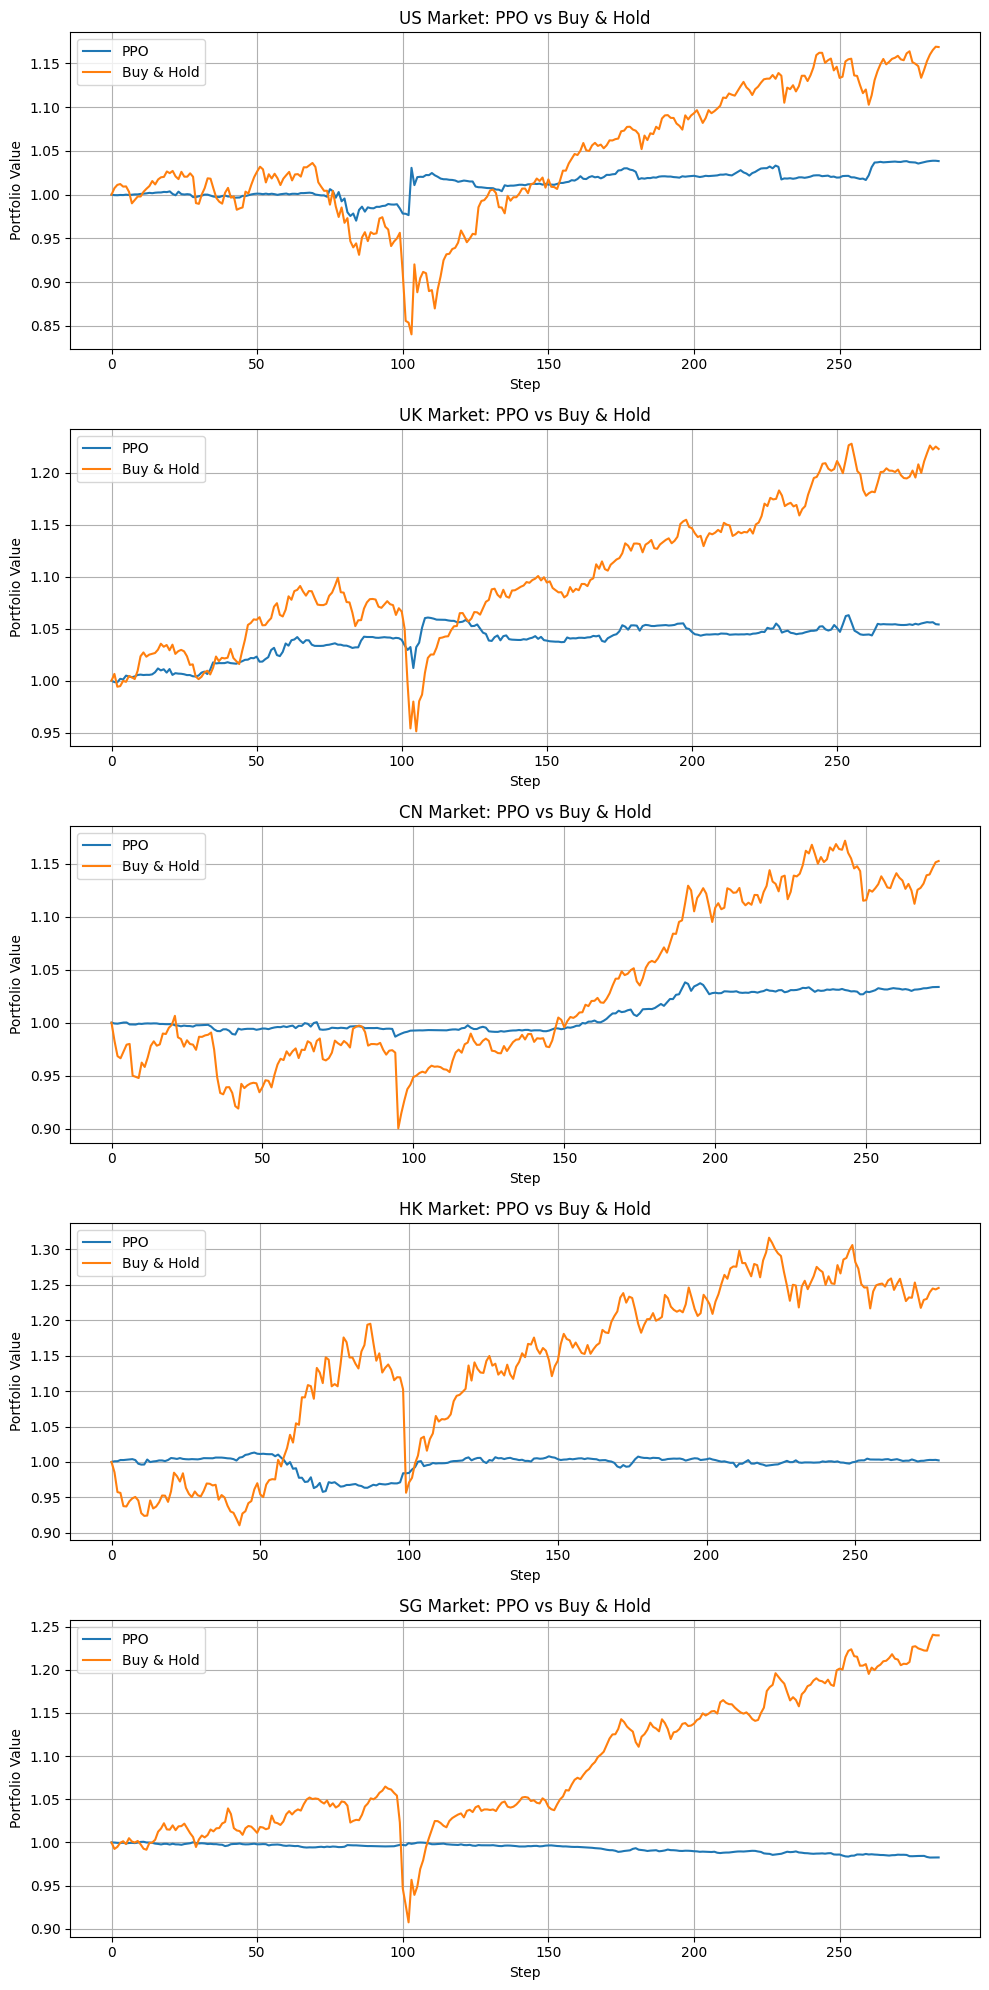

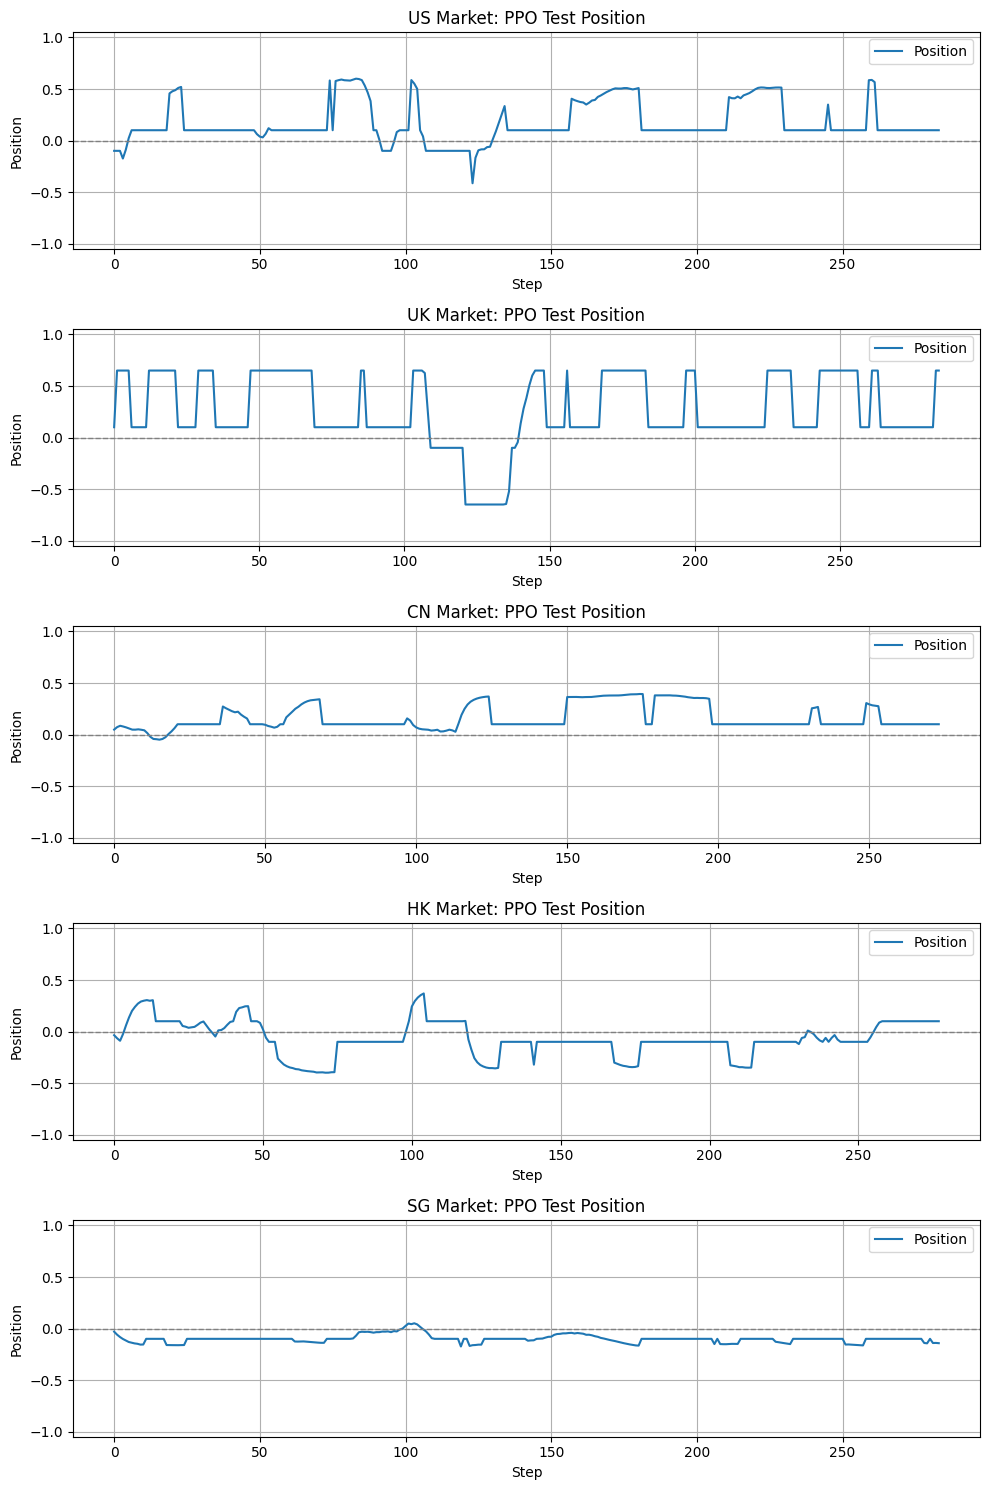

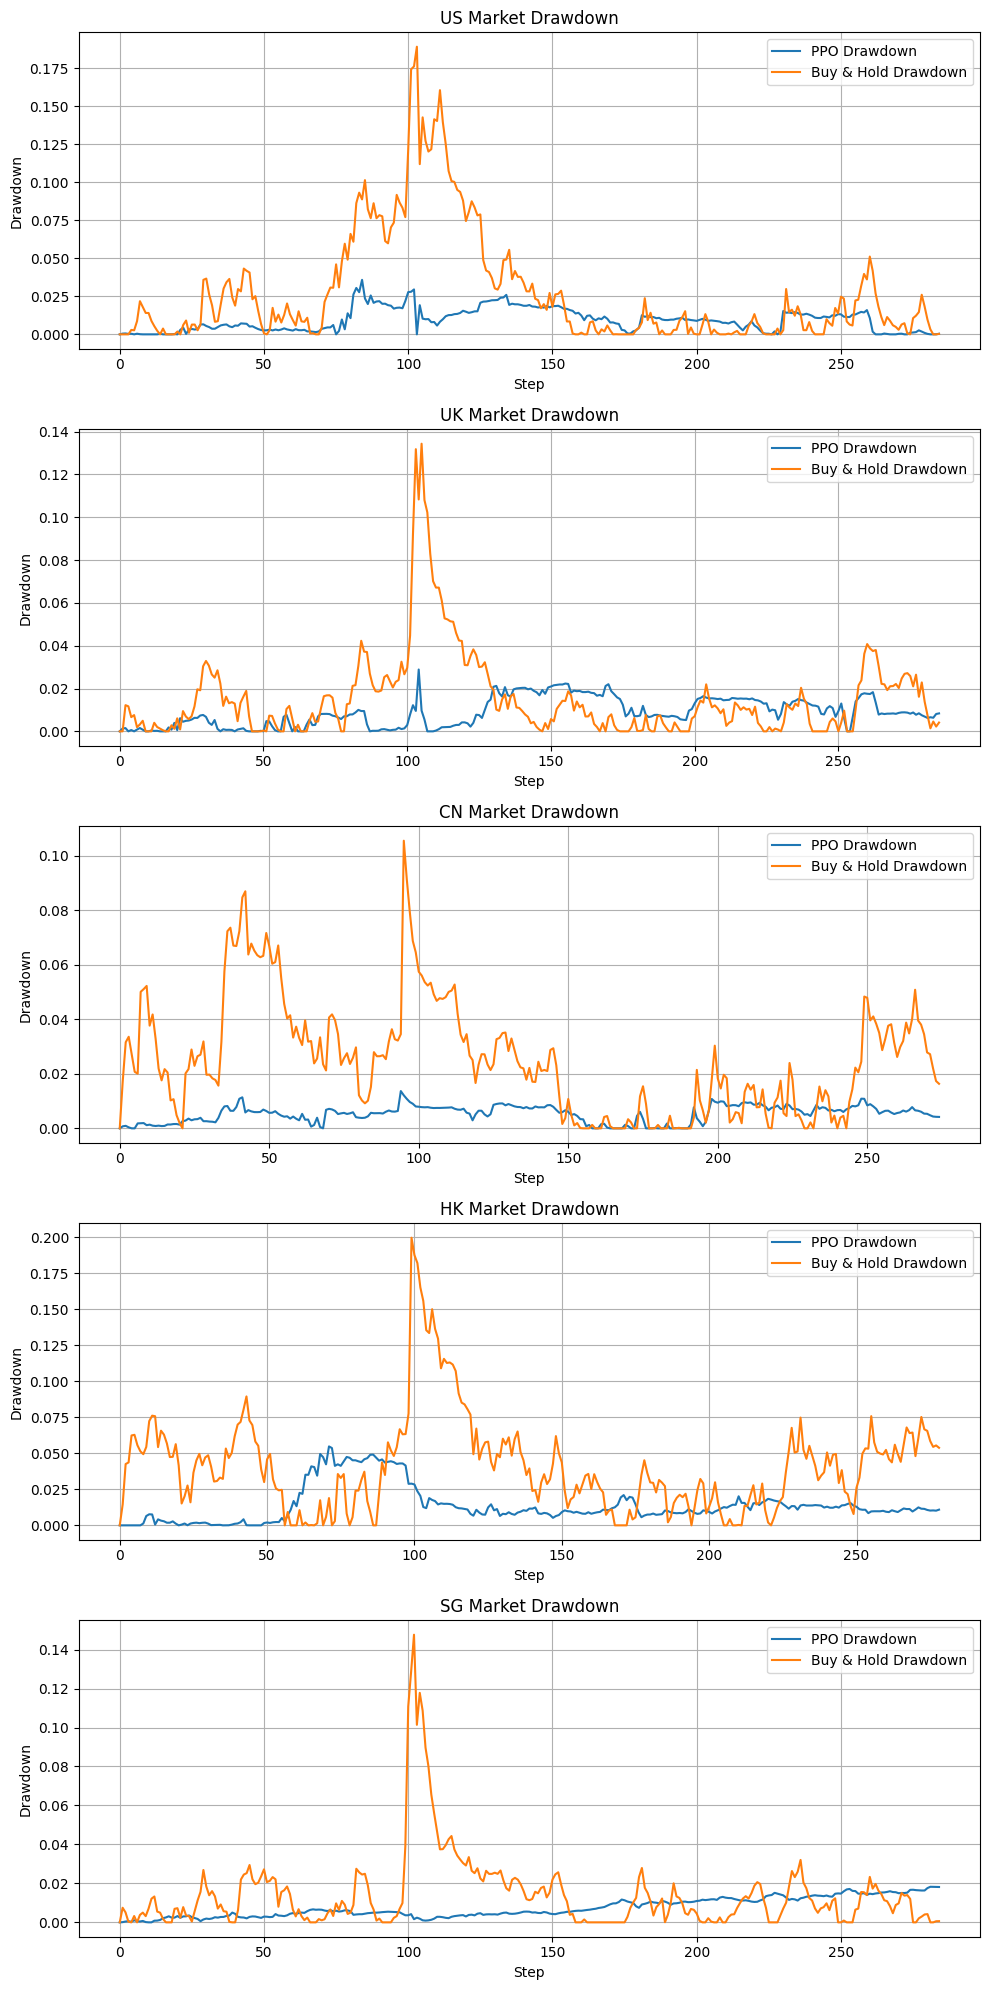

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ======================================
# Helper: compute drawdown
# ======================================
def compute_drawdown(equity):
    equity = np.array(equity)
    running_max = np.maximum.accumulate(equity)
    drawdown = (running_max - equity) / running_max
    return drawdown


# ======================================
# Equity curves (all markets)
# ======================================
fig, axes = plt.subplots(len(markets), 1, figsize=(10, 4 * len(markets)))

for i, market_name in enumerate(markets):

    ax = axes[i]

    ppo_curve = all_equity_curves[market_name]["ppo"]
    bh_curve = all_equity_curves[market_name]["buy_hold"]

    ax.plot(ppo_curve, label="PPO")
    ax.plot(bh_curve, label="Buy & Hold")

    ax.set_title(f"{market_name} Market: PPO vs Buy & Hold")
    ax.set_xlabel("Step")
    ax.set_ylabel("Portfolio Value")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


# ======================================
# Position / exposure trajectories
# ======================================
fig, axes = plt.subplots(len(markets), 1, figsize=(10, 3 * len(markets)))

for i, market_name in enumerate(markets):
    ax = axes[i]
    positions = local_test_positions.get(market_name, [])

    ax.plot(positions, label="Position")
    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{market_name} Market: PPO Test Position")
    ax.set_xlabel("Step")
    ax.set_ylabel("Position")
    ax.set_ylim([-1.05, 1.05])
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


# ======================================
# Drawdown curves
# ======================================
fig, axes = plt.subplots(len(markets), 1, figsize=(10, 4 * len(markets)))

for i, market_name in enumerate(markets):

    ax = axes[i]

    ppo_curve = all_equity_curves[market_name]["ppo"]
    bh_curve = all_equity_curves[market_name]["buy_hold"]

    ppo_dd = compute_drawdown(ppo_curve)
    bh_dd = compute_drawdown(bh_curve)

    ax.plot(ppo_dd, label="PPO Drawdown")
    ax.plot(bh_dd, label="Buy & Hold Drawdown")

    ax.set_title(f"{market_name} Market Drawdown")
    ax.set_xlabel("Step")
    ax.set_ylabel("Drawdown")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## End Summary

In [14]:
# ======================================
# End Summary (single-market run)
# ======================================
try:
    print("\nBest params:", best_params)
    print("Best validation score:", best_score)
    print("Early stopping triggered:", best_early_stopped)

    print("\nValidation metrics:")
    print(ppo_val_metrics)

    print("\nTest metrics:")
    print(ppo_test_metrics)

    avg_exp = ppo_test_metrics.get("Avg Abs Exposure", None)
    if avg_exp is not None:
        print("\nAvg abs exposure:", avg_exp)
        if avg_exp < 0.25:
            print("Note: potential underexposure (avg abs exposure < 0.25).")
except NameError:
    print("Summary skipped: run training/evaluation cells first.")



Best params: {'transaction_cost': 0.001, 'lambda_turnover': 0.0005, 'reward_return_weight': 3.0, 'low_signal_threshold': 0.2, 'high_signal_threshold': 0.5, 'low_signal_flat_bonus': 0.05, 'low_signal_exposure_penalty': 0.03, 'mid_signal_exposure_penalty': 0.01, 'high_signal_alignment_reward': 0.08, 'high_signal_wrong_way_penalty': 0.1, 'extreme_position_penalty': 0.01, 'persistence_lookback': 4, 'trend_persistence_bonus': 0.02, 'mid_signal_max_abs_position': 0.65}
Best validation score: 0.580216507185143
Early stopping triggered: True

Validation metrics:
{'Total Return': np.float64(0.06025077647992427), 'Volatility': np.float64(0.03656434959538837), 'Sharpe Ratio': np.float64(1.4381739082601248), 'Max Drawdown': np.float64(0.016857226875015032)}

Test metrics:
{'Total Return': np.float64(0.03844168256359404), 'Volatility': np.float64(0.06806076218744704), 'Sharpe Ratio': np.float64(0.5251914256162612), 'Max Drawdown': np.float64(0.03581995031888484)}
